# Mohammad Amin Kiani 4043644008
# RL - HW2 : Cliff Walking Env
# ui.ac.ir 404-405

## Needs:

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.

In [3]:
import gymnasium as gym

In [4]:
## Test
# env = gym.make(
#     "CartPole-v1",
#     render_mode="human"
# )
# obs, info = env.reset(seed=42)
#
# done = False
# while not done:
#     action = env.action_space.sample()
#     obs, reward, terminated, truncated, info = env.step(action)
#     done = terminated or truncated


StochasticCliffWalking.py

In [5]:
import sys
from contextlib import closing
from io import StringIO
import numpy as np

from gymnasium import utils
from gymnasium import Env, spaces
from gymnasium.utils import seeding
from gymnasium.utils.colorize import colorize

LEFT = 0
DOWN = 1
RIGHT = 2
UP = 3

CLIFF_MAP = [
    "FFFFFFFFFFFF",
    "FFFFFFFFFFFF",
    "FFFFFFFFFFFF",
    "SCCCCCCCCCCG"
]


def categorical_sample(prob_n, np_random):
    """
    Sample from categorical distribution
    Each row specifies class probabilities
    """
    prob_n = np.asarray(prob_n)
    csprob_n = np.cumsum(prob_n)
    np_random = np.random.rand()
    return (csprob_n > np_random).argmax()


class DiscreteEnv(Env):
    """
    Has the following members
    - nS: number of states
    - nA: number of actions
    - P: transitions (*)
    - isd: initial state distribution (**)
    (*) dictionary of lists, where
      P[s][a] == [(probability, nextstate, reward, done), ...]
    (**) list or array of length nS
    """

    def __init__(self, nS, nA, P, isd, max_length=200, termination_penalty=-50):
        self.P = P
        self.isd = isd
        self.lastaction = None
        self.nS = nS
        self.nA = nA

        self.action_space = spaces.Discrete(self.nA)
        self.observation_space = spaces.Discrete(self.nS)

        self.seed()
        self.s = categorical_sample(self.isd, self.np_random)
        self.max_length = max_length
        self.termination_penalty = termination_penalty

    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def reset(self, **kwargs):
        self.s = categorical_sample(self.isd, self.np_random)
        self.lastaction = None
        self.t = 0
        info = {}
        return int(self.s), info

    def step(self, action):
        transitions = self.P[self.s][action]
        i = categorical_sample([t[0] for t in transitions], self.np_random)
        p, s, r, d = transitions[i]
        self.s = s
        self.lastaction = action
        terminated = d
        truncated = False

        # Infinite loop check
        if self.t >= self.max_length and not terminated:
            truncated = True
            r = self.termination_penalty
        self.t += 1

        return (int(s), r, terminated, truncated, {"prob": p})


class StochasticCliffWalkingEnv(DiscreteEnv):
    metadata = {"render.modes": ["human", "ansi"]}

    def __init__(self, slip_rate=0.1, gamma=0.99, max_length=200):
        self.desc = desc = np.asarray(CLIFF_MAP, dtype="c")
        self.nrow, self.ncol = nrow, ncol = desc.shape
        self.reward_range = (-100, 0)
        self.gamma = gamma

        nA = 4
        nS = nrow * ncol

        isd = np.array(desc == b"S").astype("float64").ravel()
        isd /= isd.sum()

        P = {s: {a: [] for a in range(nA)} for s in range(nS)}

        def to_s(row, col):
            return row * ncol + col

        def inc(row, col, a):
            if a == LEFT:
                col = max(col - 1, 0)
            elif a == DOWN:
                row = min(row + 1, nrow - 1)
            elif a == RIGHT:
                col = min(col + 1, ncol - 1)
            elif a == UP:
                row = max(row - 1, 0)
            return (row, col)

        def update_probability_matrix(row, col, action):
            newrow, newcol = inc(row, col, action)
            newletter = desc[newrow, newcol]

            if newletter == b"C":
                reward = -100
                newstate = to_s(3, 0)
                done = False
            elif newletter == b"G":
                reward = 0
                newstate = to_s(newrow, newcol)
                done = True
            else:
                reward = -1
                newstate = to_s(newrow, newcol)
                done = False

            return newstate, reward, done

        for row in range(nrow):
            for col in range(ncol):
                s = to_s(row, col)
                for a in range(4):
                    li = P[s][a]
                    letter = desc[row, col]

                    if letter == b"G":
                        # Absorbing State
                        li.append((1.0, s, 0, True))
                    else:
                        if slip_rate > 0:
                            for a_prime in range(4):
                                prob = (
                                    1.0 - slip_rate) if a_prime == a else 0.0
                                prob += slip_rate / 4.0

                                if prob > 0:
                                    next_s, reward, done = update_probability_matrix(
                                        row, col, a_prime)
                                    li.append((prob, next_s, reward, done))
                        else:
                            next_s, reward, done = update_probability_matrix(
                                row, col, a)
                            li.append((1.0, next_s, reward, done))

        super(StochasticCliffWalkingEnv, self).__init__(
            nS, nA, P, isd, max_length=max_length)

    def render(self, mode="human"):
        outfile = StringIO() if mode == "ansi" else sys.stdout

        row, col = self.s // self.ncol, self.s % self.ncol
        desc = list(self.desc)
        desc = [[c.decode("utf-8") for c in line] for line in desc]

        desc[row][col] = colorize(desc[row][col], "red", highlight=True)
        if self.lastaction is not None:
            outfile.write(
                "  ({})\n".format(
                    ["Left", "Down", "Right", "Up"][self.lastaction])
            )
        else:
            outfile.write("\n")
        outfile.write("\n".join("".join(line) for line in desc) + "\n")

        if mode == "ansi":
            with closing(outfile):
                if isinstance(outfile, StringIO):
                    return outfile.getvalue()


## 1-

#### سوال (۱): تولید اپیزود

یک محیط و یک سیاست را دریافت کند و تا پایان یک اپیزود، مسیر (وضعیت‌ها، اکشن‌ها و پاداش‌ها) را تولید کند.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_episode(pi, env, render=False):
    """
    تولید یک اپیزود بر اساس سیاست داده شده.

    ورودی ها:
    pi: تابع سیاست که وضعیت را می گیرد و توزیع احتمالاتی روی اکشن ها برمی گرداند.
    env: محیط بازی
    render: در صورت True بودن، محیط چاپ می شود.

    خروجی ها:
    states, actions, rewards
    """
    states = []
    actions = []
    rewards = []

    state, _ = env.reset()
    done = False
    truncated = False

    while not (done or truncated):
        if render:
            env.render()

        # دریافت احتمالات اکشن برای وضعیت فعلی از سیاست
        action_probs = pi(state)
        # انتخاب اکشن بر اساس توزیع احتمالاتی
        action = np.random.choice(len(action_probs), p=action_probs)

        # انجام اکشن در محیط
        next_state, reward, done, truncated, _ = env.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(reward)

        state = next_state

    return states, actions, rewards

#### سوال (۲): مونت کارلوی اولین بازدید

In [7]:
from collections import defaultdict

def make_epsilon_soft_policy(Q, epsilon, nA):
    """
    ایجاد یک تابع سیاست e-soft بر اساس مقادیر Q
    """
    def policy_fn(observation):
        A = np.ones(nA, dtype=float) * epsilon / nA
        best_action = np.argmax(Q[observation])
        A[best_action] += (1.0 - epsilon)
        return A
    return policy_fn

def mc_control_epsilon_soft(env, num_episodes, epsilon, gamma=0.99):
    """
    First-visit Monte Carlo Control با سیاست epsilon-soft
    """
    nA = env.action_space.n
    # مقداردهی اولیه Q به صورت صفر (یا تصادفی)
    Q = defaultdict(lambda: np.zeros(nA))
    # دیکشنری برای نگهداری تمام بازده‌های (Return) دیده شده برای جفت (وضعیت، اکشن)
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    # سیاستی که در طول یادگیری بهبود می یابد
    policy = make_epsilon_soft_policy(Q, epsilon, nA)

    for ep in range(num_episodes):
        if (ep+1) % 1000 == 0:
            print(f"\rEpisode {ep+1}/{num_episodes}", end="")

        # تولید یک اپیزود
        states, actions, rewards = generate_episode(policy, env, render=False)

        # محاسبه بازده ها (G) از انتهای اپیزود به ابتدا
        G = 0
        # برای First-Visit باید بررسی کنیم که آیا جفت (وضعیت، اکشن) قبلاً در این اپیزود دیده شده یا خیر
        visited_state_actions = set()

        for t in range(len(states)-1, -1, -1):
            state = states[t]
            action = actions[t]
            reward = rewards[t]

            G = gamma * G + reward
            state_action = (state, action)

            # در الگوریتم First-Visit، فقط اولین باری که در اپیزود به (s, a) می رسیم آپدیت را انجام می دهیم
            if state_action not in zip(states[:t], actions[:t]):
                visited_state_actions.add(state_action)
                returns_sum[state_action] += G
                returns_count[state_action] += 1

                # به روز رسانی میانگین Q
                Q[state][action] = returns_sum[state_action] / returns_count[state_action]
                # سیاست به طور خودکار به روز می شود چون به Q ارجاع دارد

    return Q, policy

# توابع کمکی برای نمایش مسیر
def get_path(env, policy):
    """استخراج مسیر با انتخاب بهترین اکشن (بدون اکتشاف تصادفی)"""
    # در مرحله تست، مسیر را کاملا حریصانه نسبت به Q تولید میکنیم
    def greedy_policy(state):
        probs = np.zeros(env.action_space.n)
        best_a = np.argmax(policy(state)) # policy(state) gives e-soft probs, max prob is greedy action
        probs[best_a] = 1.0
        return probs

    states, _, _ = generate_episode(greedy_policy, env, render=False)
    return states

def print_path_on_grid(env, path):
    nrow, ncol = env.nrow, env.ncol
    grid = np.array([['.' for _ in range(ncol)] for _ in range(nrow)])

    # مشخص کردن شروع، هدف و صخره
    for r in range(nrow):
        for c in range(ncol):
            if env.desc[r, c] == b'S': grid[r, c] = 'S'
            elif env.desc[r, c] == b'G': grid[r, c] = 'G'
            elif env.desc[r, c] == b'C': grid[r, c] = 'C'

    # رسم مسیر
    for s in path[:-1]:
        r, c = s // ncol, s % ncol
        if grid[r, c] not in ['S', 'G']:
            grid[r, c] = '*'

    print("\n" + "\n".join([''.join(row) for row in grid]))


# --- اجرای سوال 2 ---
# ساخت محیط
# در اینجا از کد تی ای استفاده میکنیم
env = StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200)

print("\n--- Training MC for epsilon = 0.1 ---")
Q_01, policy_01 = mc_control_epsilon_soft(env, num_episodes=5000, epsilon=0.1)
print("\nSample path for epsilon = 0.1:")
path_01 = get_path(env, policy_01)
print_path_on_grid(env, path_01)

print("\n--- Training MC for epsilon = 0.01 ---")
Q_001, policy_001 = mc_control_epsilon_soft(env, num_episodes=5000, epsilon=0.01)
print("\nSample path for epsilon = 0.01:")
path_001 = get_path(env, policy_001)
print_path_on_grid(env, path_001)


--- Training MC for epsilon = 0.1 ---
Episode 5000/5000
Sample path for epsilon = 0.1:

..*********.
***.**....**
*...........
SCCCCCCCCCCG

--- Training MC for epsilon = 0.01 ---
Episode 5000/5000
Sample path for epsilon = 0.01:

.*********..
.*..**...**.
**........*.
SCCCCCCCCCCG


مسیر حرکت عامل (*)

 نقطه شروع (S)

  سمت هدف (G)

   صخره (C)


#### سوال (۳): رسم نمودار پایداری یادگیری (۱۰ اجرای مستقل)

Running 10 independent trials...
Trial 1/10
Trial 2/10
Trial 3/10
Trial 4/10
Trial 5/10
Trial 6/10
Trial 7/10
Trial 8/10
Trial 9/10
Trial 10/10


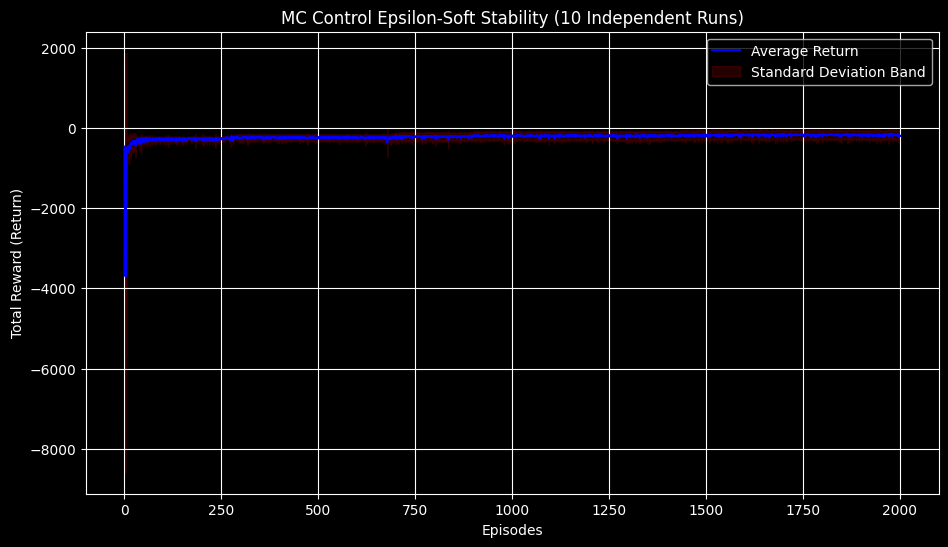

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def mc_control_epsilon_soft_with_history(env, num_episodes, epsilon, gamma=0.99):
    nA = env.action_space.n
    Q = defaultdict(lambda: np.zeros(nA))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)
    policy = make_epsilon_soft_policy(Q, epsilon, nA)

    # برای ذخیره پاداش کل هر اپیزود در طول یادگیری
    episode_rewards = []

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode(policy, env, render=False)
        episode_rewards.append(sum(rewards)) # مجموع پاداش های اپیزود جاری

        G = 0
        for t in range(len(states)-1, -1, -1):
            state = states[t]
            action = actions[t]
            G = gamma * G + rewards[t]
            state_action = (state, action)

            if state_action not in zip(states[:t], actions[:t]):
                returns_sum[state_action] += G
                returns_count[state_action] += 1
                Q[state][action] = returns_sum[state_action] / returns_count[state_action]

    return episode_rewards, Q, policy

# اجرای ۱۰ بار مستقل الگوریتم
num_runs = 10
num_episodes = 2000
epsilon = 0.1
all_runs_rewards = []

print("Running 10 independent trials...")
for run in range(num_runs):
    print(f"Trial {run+1}/{num_runs}")
    rewards_history, Q_final, pol_final = mc_control_epsilon_soft_with_history(env, num_episodes, epsilon)
    all_runs_rewards.append(rewards_history)

all_runs_rewards = np.array(all_runs_rewards) # ابعاد: (10, 2000)

# محاسبه میانگین و انحراف معیار روی ۱۰ اجرا
mean_rewards = np.mean(all_runs_rewards, axis=0)
std_rewards = np.std(all_runs_rewards, axis=0)

# رسم نمودار همراه با نوار انحراف معیار
plt.figure(figsize=(11, 6))
episodes_range = np.arange(1, num_episodes + 1)
plt.plot(episodes_range, mean_rewards, label='Average Return', color='blue')
plt.fill_between(episodes_range, mean_rewards - std_rewards, mean_rewards + std_rewards, color='red', alpha=0.15, label='Standard Deviation Band')
plt.xlabel('Episodes')
plt.ylabel('Total Reward (Return)')
plt.title('MC Control Epsilon-Soft Stability (10 Independent Runs)')
plt.legend()
plt.grid(True)
plt.show()

#### سوال (۴): پیش‌بینی ارزش با نمونه‌برداری اهمیت

Sampling Episode 10000/10000

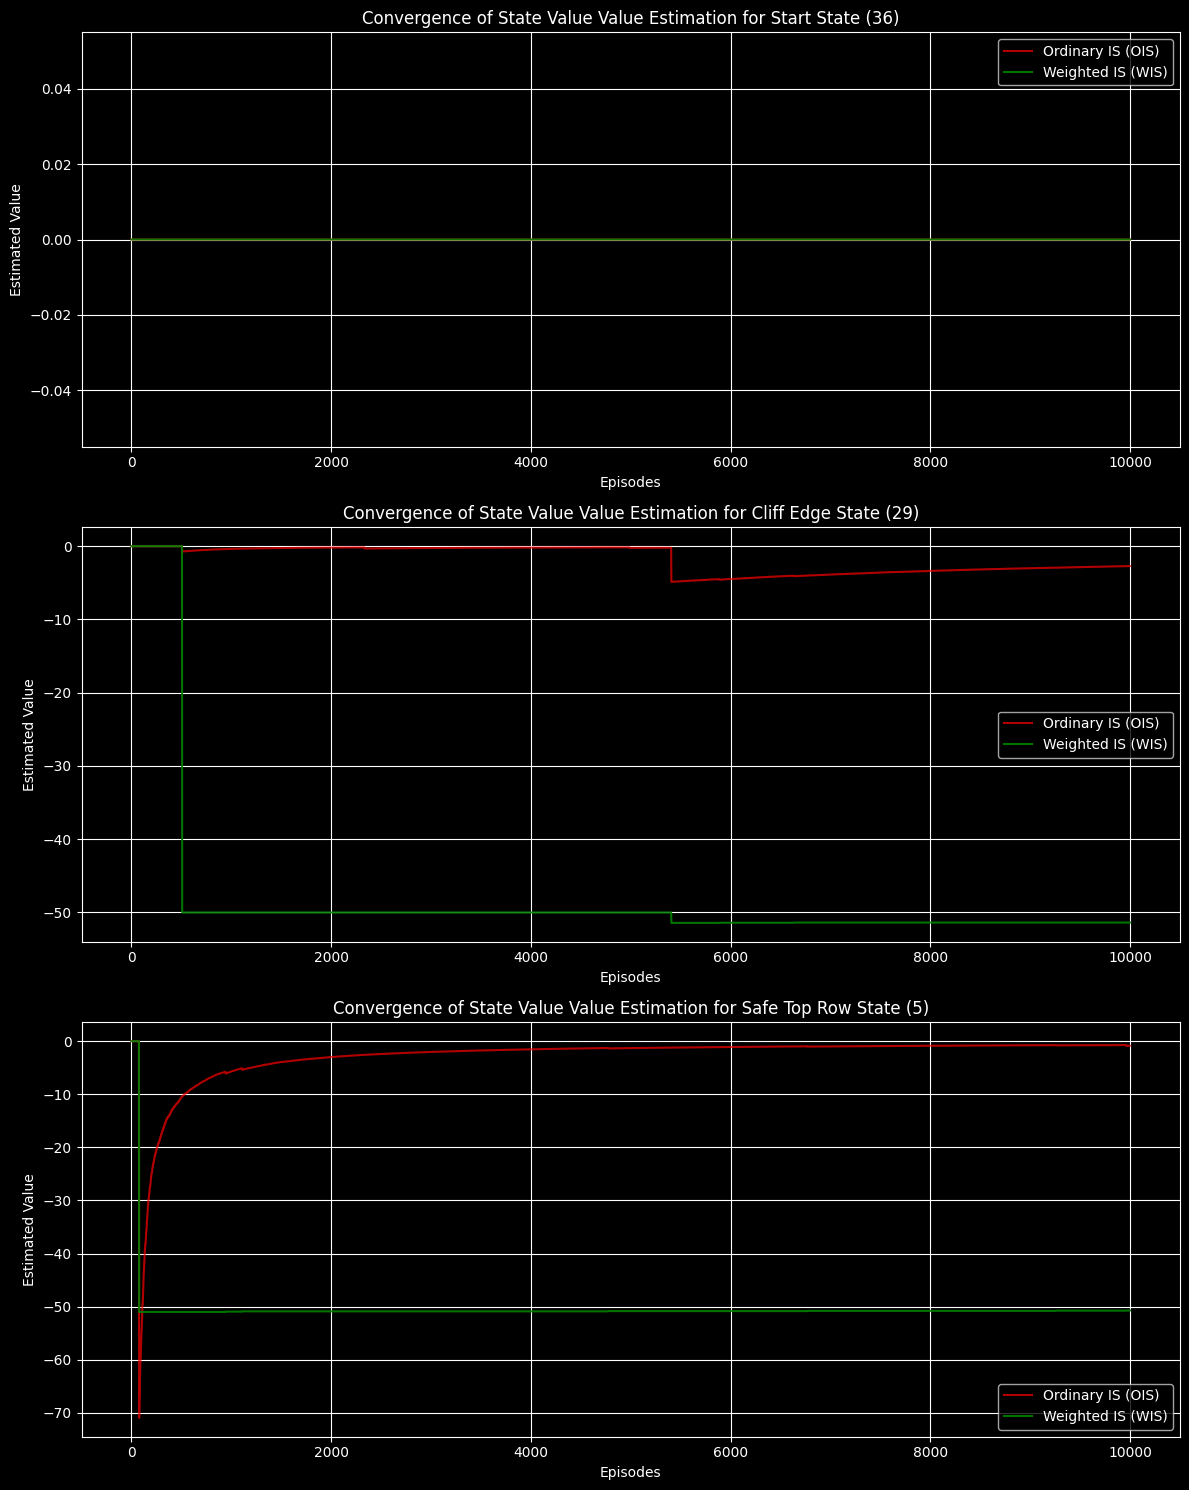

In [7]:
def uniform_behavior_policy(state):
    return np.ones(4) * 0.25

# فرض میکنیم سیاست حریصانه هدف را از Q_01 سوال قبل بدست آورده ایم
def target_greedy_policy_fn(state, Q_table):
    best_action = np.argmax(Q_table[state])
    probs = np.zeros(4)
    probs[best_action] = 1.0
    return probs

def importance_sampling_evaluation(env, Q_target, num_episodes=10000, gamma=0.99):
    target_states = [36, 29, 5]

    # آرایه‌های ذخیره روند همگرایی
    V_OIS = {s: np.zeros(num_episodes) for s in target_states}
    V_WIS = {s: np.zeros(num_episodes) for s in target_states}

    # متغیرهای به روز رسانی افزایشی
    # برای OIS: تعداد دفعات بازدید وضعیت (Count)
    counts_OIS = {s: 0 for s in target_states}
    values_OIS = {s: 0.0 for s in target_states}

    # برای WIS: مجموع وزن های اهمیت (C)
    sum_weights_WIS = {s: 0.0 for s in target_states}
    values_WIS = {s: 0.0 for s in target_states}

    for ep in range(num_episodes):
        if (ep+1) % 2000 == 0:
            print(f"\rSampling Episode {ep+1}/{num_episodes}", end="")

        # تولید اپیزود با سیاست رفتار (کاملا تصادفی)
        states, actions, rewards = generate_episode(uniform_behavior_policy, env, render=False)

        # بررسی هر یک از وضعیت های هدف
        for s_target in target_states:
            if s_target in states:
                # یافتن اولین زمان بازدید (First-visit)
                first_occ = states.index(s_target)

                # محاسبه بازده (G) از آن زمان به بعد
                G = 0
                discount = 1.0
                for t in range(first_occ, len(states)):
                    G += discount * rewards[t]
                    discount *= gamma

                # محاسبه نسبت نمونه برداری اهمیت (rho)
                rho = 1.0
                for t in range(first_occ, len(states)):
                    state_t = states[t]
                    action_t = actions[t]

                    pi_prob = target_greedy_policy_fn(state_t, Q_target)[action_t]
                    mu_prob = 0.25 # uniform random

                    rho *= (pi_prob / mu_prob)
                    if rho == 0: # اگر سیاست هدف هرگز این اکشن را انتخاب نمیکرد
                        break

                # ۱. به روز رسانی افزایشی Ordinary Importance Sampling
                counts_OIS[s_target] += 1
                values_OIS[s_target] += (1.0 / counts_OIS[s_target]) * (rho * G - values_OIS[s_target])

                # ۲. به روز رسانی افزایشی Weighted Importance Sampling
                if rho > 0:
                    sum_weights_WIS[s_target] += rho
                    if sum_weights_WIS[s_target] > 0:
                        values_WIS[s_target] += (rho / sum_weights_WIS[s_target]) * (G - values_WIS[s_target])

        # ذخیره مقادیر در هر اپیزود برای نمودار
        for s_target in target_states:
            V_OIS[s_target][ep] = values_OIS[s_target]
            V_WIS[s_target][ep] = values_WIS[s_target]

    return V_OIS, V_WIS

# اجرای الگوریتم نمونه برداری اهمیت
V_OIS, V_WIS = importance_sampling_evaluation(env, Q_01, num_episodes=10000)

# رسم نمودارها
fig, axs = plt.subplots(3, 1, figsize=(12, 15))
states_list = [36, 29, 5]
titles = {36: "Start State (36)", 29: "Cliff Edge State (29)", 5: "Safe Top Row State (5)"}

for i, s in enumerate(states_list):
    axs[i].plot(V_OIS[s], label='Ordinary IS (OIS)', color='red', alpha=0.7)
    axs[i].plot(V_WIS[s], label='Weighted IS (WIS)', color='green', alpha=0.9)
    axs[i].set_title(f"Convergence of State Value Value Estimation for {titles[s]}")
    axs[i].set_xlabel('Episodes')
    axs[i].set_ylabel('Estimated Value')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

## 2-

#### گام صفر: محاسبه ارزش واقعی با ارزیابی سیاست تکراری 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def compute_true_values(env, gamma=0.99, theta=1e-8):
    """محاسبه ارزش واقعی وضعیت‌ها (Ground Truth) برای یک سیاست کاملاً تصادفی یکنواخت"""
    V = np.zeros(env.nS)
    pi = np.ones((env.nS, env.nA)) * 0.25  # احتمال 0.25 برای هر 4 اکشن

    while True:
        delta = 0
        for s in range(env.nS):
            v_old = V[s]
            new_v = 0
            for a in range(env.nA):
                # در این محیط P[s][a] شامل لیستی از توپل‌های (prob, next_s, reward, done) است
                for prob, next_s, reward, done in env.P[s][a]:
                    if done:
                        new_v += pi[s][a] * prob * reward
                    else:
                        new_v += pi[s][a] * prob * (reward + gamma * V[next_s])

            V[s] = new_v
            delta = max(delta, abs(v_old - V[s]))

        if delta < theta:
            break

    return V

# محاسبه ارزش مرجع
V_true = compute_true_values(env)
print("True values calculated successfully.")

True values calculated successfully.


#### سوال (۱): مقایسه مونت کارلوی هر بازدید و تفاوت زمانی

Training MC Prediction...
Training TD(0) Prediction...


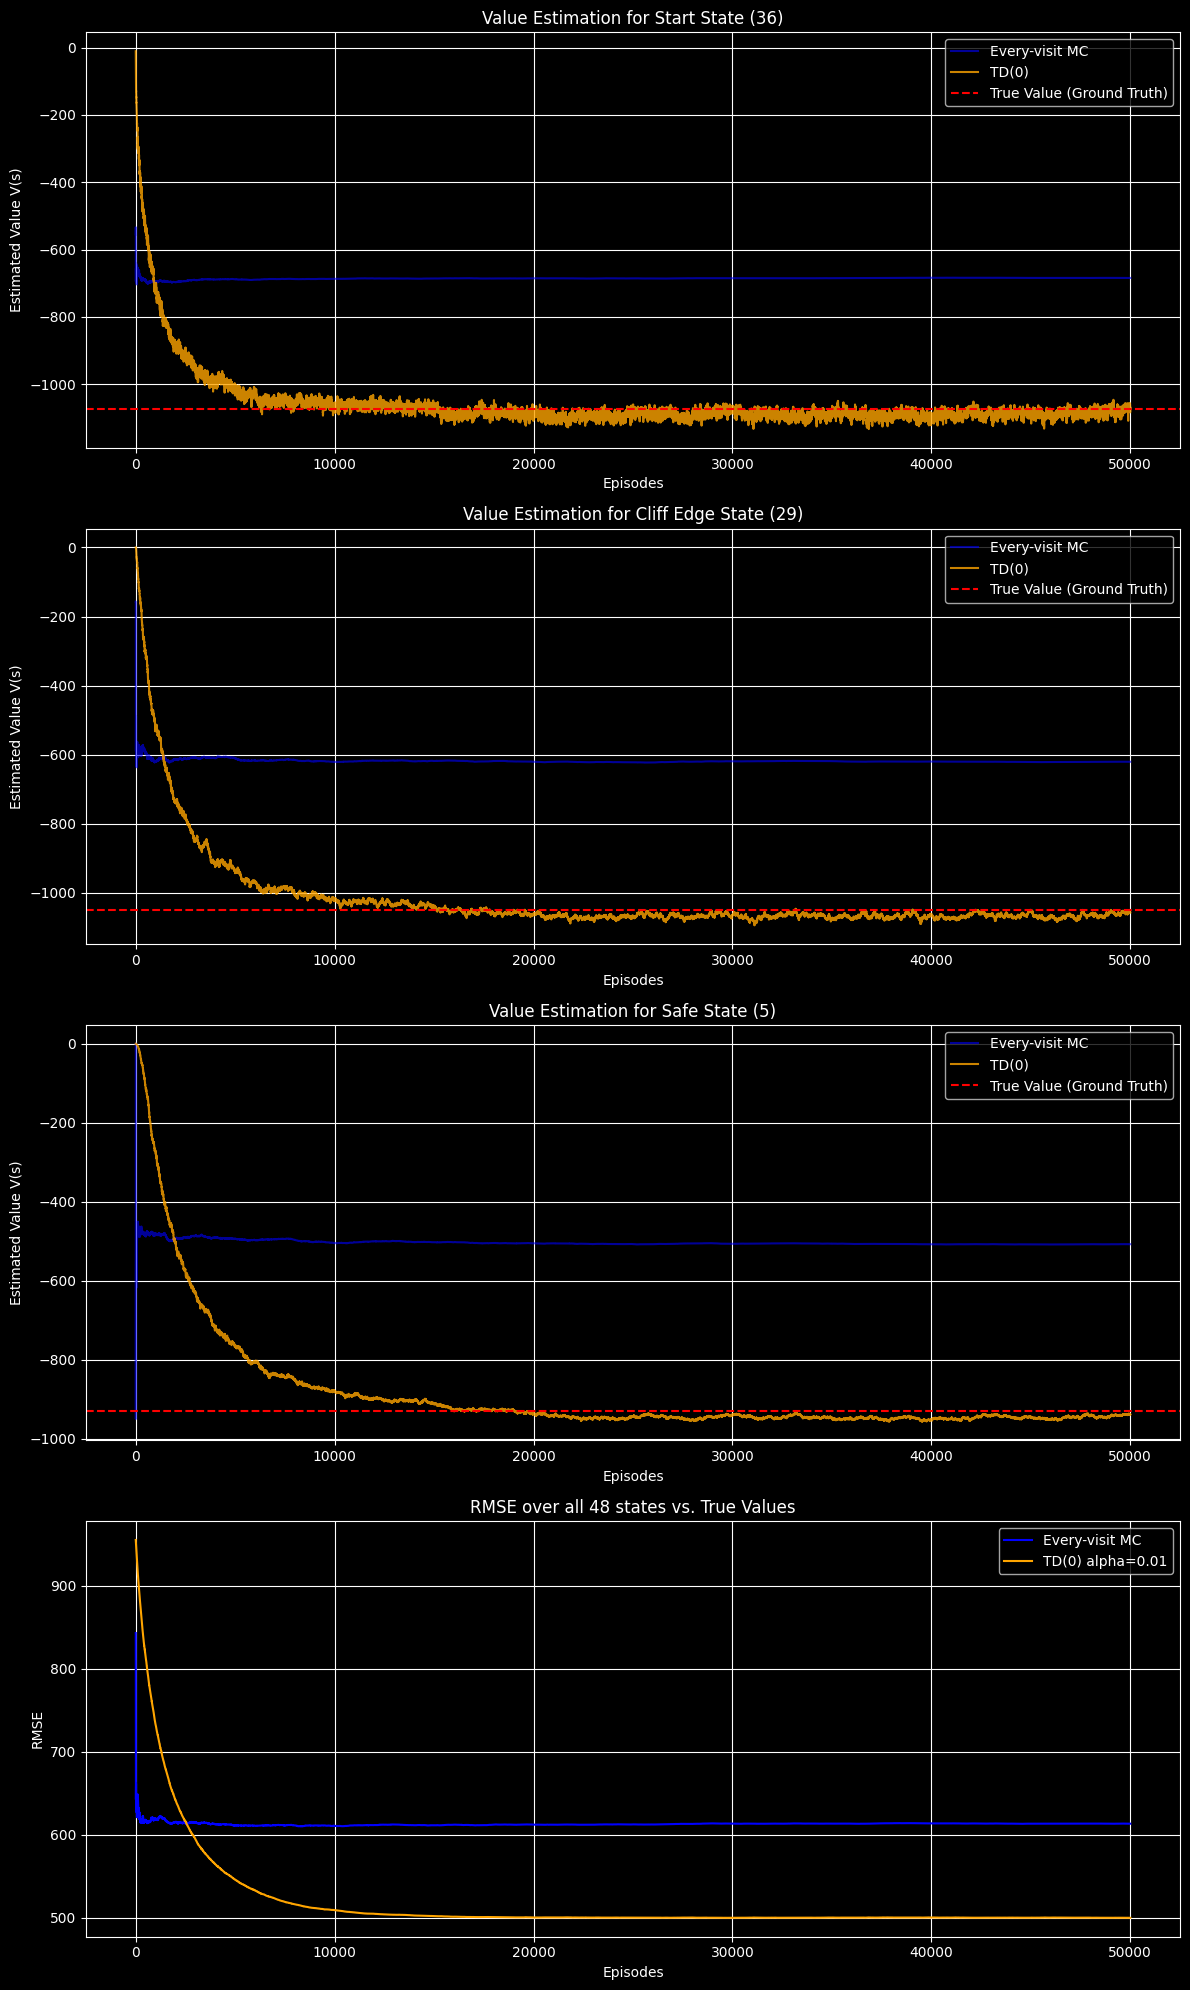

In [9]:
def generate_random_episode(env):
    """تولید اپیزود با سیاست کاملاً تصادفی"""
    states, rewards = [], []
    s, _ = env.reset()
    done, truncated = False, False
    while not (done or truncated):
        a = np.random.choice(4)
        next_s, r, done, truncated, _ = env.step(a)
        states.append(s)
        rewards.append(r)
        s = next_s
    return states, rewards

def every_visit_mc_prediction(env, V_true, num_episodes=50000):
    V = np.zeros(env.nS)
    N = np.zeros(env.nS) # برای میانگین‌گیری ضمنی MC
    V_history = {36: [], 29: [], 5: []}
    rmse_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        states, rewards = generate_random_episode(env)
        G = 0
        for t in range(len(states)-1, -1, -1):
            s = states[t]
            G = env.gamma * G + rewards[t]
            N[s] += 1
            V[s] += (1.0 / N[s]) * (G - V[s]) # فرمول میانگین‌گیری افزایشی

        # ذخیره تاریخچه برای وضعیت‌های خاص و خطای کل
        for state in [36, 29, 5]:
            V_history[state].append(V[state])
        rmse_history[ep] = np.sqrt(np.mean((V - V_true)**2))

    return V, V_history, rmse_history

def td_zero_prediction(env, V_true, alpha=0.01, num_episodes=50000):
    V = np.zeros(env.nS)
    V_history = {36: [], 29: [], 5: []}
    rmse_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        s, _ = env.reset()
        done, truncated = False, False
        while not (done or truncated):
            a = np.random.choice(4)
            next_s, r, done, truncated, _ = env.step(a)

            # فرمول به روز رسانی TD(0)
            td_target = r if done else r + env.gamma * V[next_s]
            V[s] += alpha * (td_target - V[s])
            s = next_s

        for state in [36, 29, 5]:
            V_history[state].append(V[state])
        rmse_history[ep] = np.sqrt(np.mean((V - V_true)**2))

    return V, V_history, rmse_history

print("Training MC Prediction...")
V_mc, v_hist_mc, rmse_mc = every_visit_mc_prediction(env, V_true)

print("Training TD(0) Prediction...")
V_td, v_hist_td, rmse_td = td_zero_prediction(env, V_true)

# --- رسم نمودارها (الف) و (ب) ---
fig, axs = plt.subplots(4, 1, figsize=(12, 20))
states_to_plot = [36, 29, 5]
titles = {36: "Start State (36)", 29: "Cliff Edge State (29)", 5: "Safe State (5)"}

for i, state in enumerate(states_to_plot):
    axs[i].plot(v_hist_mc[state], label='Every-visit MC', color='blue', alpha=0.6)
    axs[i].plot(v_hist_td[state], label='TD(0)', color='orange', alpha=0.8)
    axs[i].axhline(y=V_true[state], color='red', linestyle='--', label='True Value (Ground Truth)')
    axs[i].set_title(f"Value Estimation for {titles[state]}")
    axs[i].set_xlabel('Episodes')
    axs[i].set_ylabel('Estimated Value V(s)')
    axs[i].legend()
    axs[i].grid(True)

# نمودار RMSE
axs[3].plot(rmse_mc, label='Every-visit MC', color='blue')
axs[3].plot(rmse_td, label='TD(0) alpha=0.01', color='orange')
axs[3].set_title("RMSE over all 48 states vs. True Values")
axs[3].set_xlabel('Episodes')
axs[3].set_ylabel('RMSE')
axs[3].legend()
axs[3].grid(True)

plt.tight_layout()
plt.show()

  #### سوال (۲): پیش‌بینی ان حرکت تفاوت زمانی و موازنه بایاس-واریانس

Training n-step TD...
Running n=1...
Running n=2...
Running n=4...
Running n=8...
Running n=100...


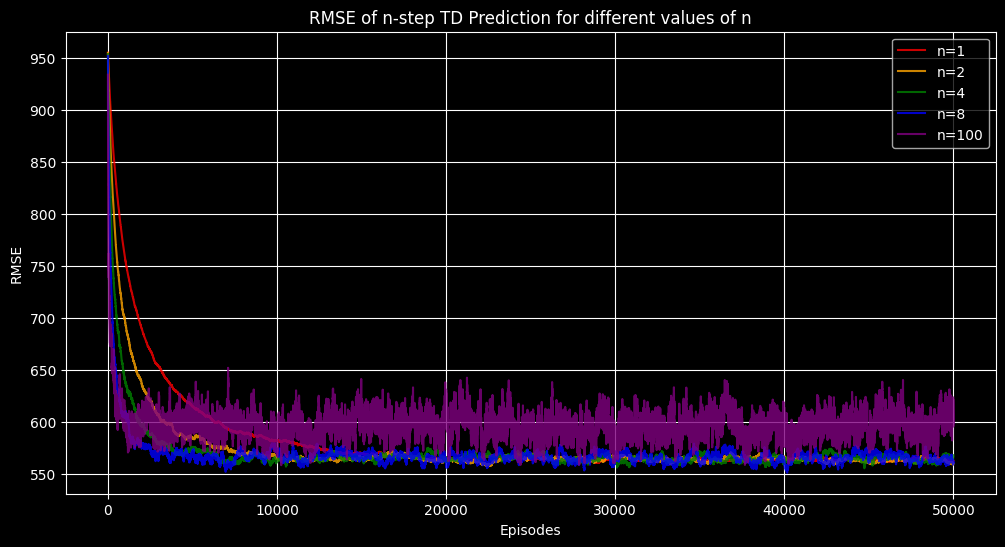

In [10]:
def n_step_td_prediction(env, V_true, n, alpha=0.01, num_episodes=50000):
    V = np.zeros(env.nS)
    rmse_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        s, _ = env.reset()
        states = [s]
        rewards = [0] # ایندکس 0 استفاده نمیشود تا R_1 با t=0 هماهنگ باشد
        T = float('inf')
        t = 0

        while True:
            if t < T:
                a = np.random.choice(4)
                next_s, r, done, truncated, _ = env.step(a)
                states.append(next_s)
                rewards.append(r)
                if done or truncated:
                    T = t + 1

            tau = t - n + 1 # زمان وضعیتی که باید آپدیت شود
            if tau >= 0:
                # محاسبه بازده n-step
                G = 0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (env.gamma**(i - tau - 1)) * rewards[i]

                if tau + n < T:
                    G += (env.gamma**n) * V[states[tau + n]]

                update_s = states[tau]
                V[update_s] += alpha * (G - V[update_s])

            if tau == T - 1:
                break
            t += 1

        rmse_history[ep] = np.sqrt(np.mean((V - V_true)**2))

    return rmse_history

n_values = [1, 2, 4, 8, 100]
n_step_rmses = {}

print("Training n-step TD...")
for n in n_values:
    print(f"Running n={n}...")
    n_step_rmses[n] = n_step_td_prediction(env, V_true, n=n)

plt.figure(figsize=(12, 6))
colors = ['red', 'orange', 'green', 'blue', 'purple']
for i, n in enumerate(n_values):
    plt.plot(n_step_rmses[n], label=f'n={n}', color=colors[i], alpha=0.8)

plt.title("RMSE of n-step TD Prediction for different values of n")
plt.xlabel("Episodes")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

#### سوال (۳): هم‌ارزی تفاوت زمانی ان حالته و مونت کارلو (بخش امتیازی)

الف) اثبات ریاضی: در گزارش کتبی

ب) اثبات تجربی (کد):

Training n-step TD with Dynamic Alpha...


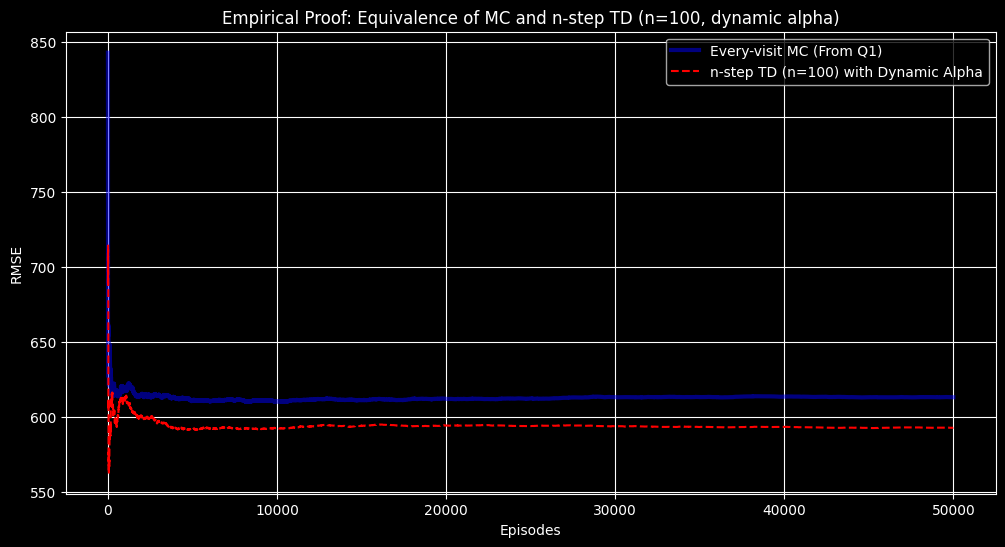

In [11]:
def n_step_td_equivalent_mc(env, V_true, n=100, num_episodes=50000):
    V = np.zeros(env.nS)
    N = np.zeros(env.nS) # برای محاسبه آلفای پویا
    rmse_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        s, _ = env.reset()
        states = [s]
        rewards = [0]
        T = float('inf')
        t = 0

        while True:
            if t < T:
                a = np.random.choice(4)
                next_s, r, done, truncated, _ = env.step(a)
                states.append(next_s)
                rewards.append(r)
                if done or truncated:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (env.gamma**(i - tau - 1)) * rewards[i]
                if tau + n < T:
                    G += (env.gamma**n) * V[states[tau + n]]

                update_s = states[tau]

                # --- تغییر حیاتی برای هم ارزی با MC ---
                N[update_s] += 1
                dynamic_alpha = 1.0 / N[update_s]
                # -------------------------------------

                V[update_s] += dynamic_alpha * (G - V[update_s])

            if tau == T - 1:
                break
            t += 1

        rmse_history[ep] = np.sqrt(np.mean((V - V_true)**2))

    return rmse_history

print("Training n-step TD with Dynamic Alpha...")
rmse_n_step_dynamic = n_step_td_equivalent_mc(env, V_true, n=100)

plt.figure(figsize=(12, 6))
plt.plot(rmse_mc, label='Every-visit MC (From Q1)', color='blue', linewidth=3, alpha=0.5)
plt.plot(rmse_n_step_dynamic, label='n-step TD (n=100) with Dynamic Alpha', color='red', linestyle='--', linewidth=1.5)
plt.title("Empirical Proof: Equivalence of MC and n-step TD (n=100, dynamic alpha)")
plt.xlabel("Episodes")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

## 3

 #### سوال ۱ و ۲: Q-Learning ،SARSA و Expected SARSA

Running SARSA...
Algorithm: sarsa | Run 1/10 completed.
Algorithm: sarsa | Run 2/10 completed.
Algorithm: sarsa | Run 3/10 completed.
Algorithm: sarsa | Run 4/10 completed.
Algorithm: sarsa | Run 5/10 completed.
Algorithm: sarsa | Run 6/10 completed.
Algorithm: sarsa | Run 7/10 completed.
Algorithm: sarsa | Run 8/10 completed.
Algorithm: sarsa | Run 9/10 completed.
Algorithm: sarsa | Run 10/10 completed.

Running Q-Learning...
Algorithm: q_learning | Run 1/10 completed.
Algorithm: q_learning | Run 2/10 completed.
Algorithm: q_learning | Run 3/10 completed.
Algorithm: q_learning | Run 4/10 completed.
Algorithm: q_learning | Run 5/10 completed.
Algorithm: q_learning | Run 6/10 completed.
Algorithm: q_learning | Run 7/10 completed.
Algorithm: q_learning | Run 8/10 completed.
Algorithm: q_learning | Run 9/10 completed.
Algorithm: q_learning | Run 10/10 completed.

Running Expected SARSA...
Algorithm: expected_sarsa | Run 1/10 completed.
Algorithm: expected_sarsa | Run 2/10 completed.
Algor

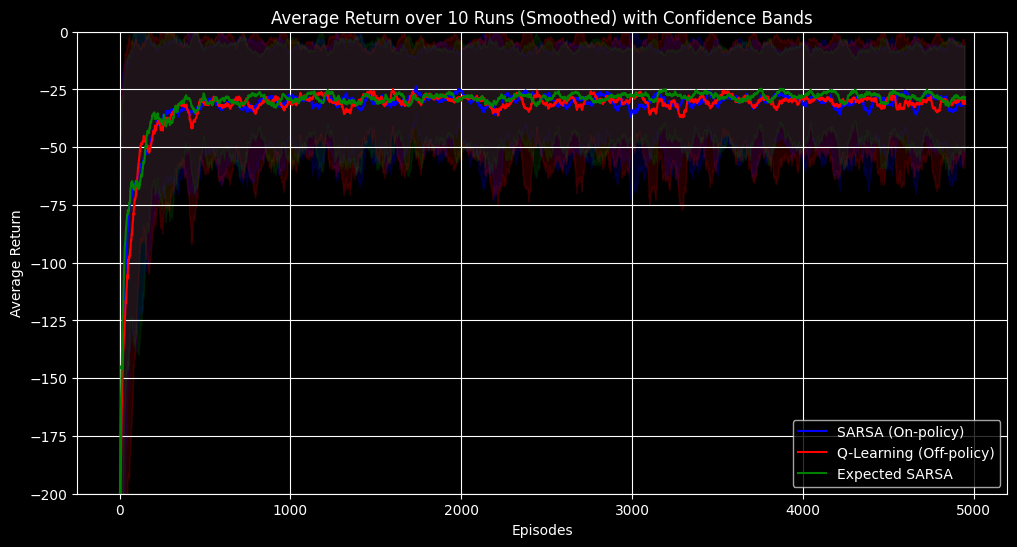


--- SARSA Learned Policy ---
→ → → → → → → → → → → ↓
↑ ↑ ← ↑ → ↑ ↑ → ↑ → ↑ ↓
↑ ↑ → ↑ ↑ → ↑ ↑ → ← → ↓
S C C C C C C C C C C G

--- Q-Learning Learned Policy ---
→ → → → → → → → → ↓ ↓ ↓
→ → → → → → → → → → → ↓
↑ ↑ ↑ → → ↑ ↑ → ↑ → → ↓
S C C C C C C C C C C G


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def epsilon_greedy_action(Q, state, epsilon=0.1, nA=4):
    """انتخاب عمل بر اساس سیاست اپسیلون-حریصانه"""
    if np.random.rand() < epsilon:
        return np.random.choice(nA)
    else:
        # در صورت برابر بودن ارزش‌ها، تصادفی یکی از بهترین‌ها انتخاب شود
        best_actions = np.argwhere(Q[state] == np.amax(Q[state])).flatten()
        return np.random.choice(best_actions)

def run_td_control_experiment(env, algo, num_episodes=5000, runs=10, alpha=0.1, epsilon=0.1, gamma=0.99):
    """اجرای الگوریتم برای چندین بار مستقل جهت محاسبه میانگین و نوار اطمینان"""
    all_returns = np.zeros((runs, num_episodes))
    final_Q = None

    for run in range(runs):
        Q = np.zeros((env.nS, env.nA))
        for ep in range(num_episodes):
            s, _ = env.reset()
            a = epsilon_greedy_action(Q, s, epsilon)
            G = 0
            done, truncated = False, False

            while not (done or truncated):
                next_s, r, done, truncated, _ = env.step(a)
                G += r

                if algo == 'sarsa':
                    next_a = epsilon_greedy_action(Q, next_s, epsilon)
                    target = r + gamma * Q[next_s, next_a] * (not done)
                    Q[s, a] += alpha * (target - Q[s, a])
                    a = next_a

                elif algo == 'q_learning':
                    target = r + gamma * np.max(Q[next_s]) * (not done)
                    Q[s, a] += alpha * (target - Q[s, a])
                    a = epsilon_greedy_action(Q, next_s, epsilon)

                elif algo == 'expected_sarsa':
                    best_actions = np.argwhere(Q[next_s] == np.amax(Q[next_s])).flatten()
                    prob = np.ones(env.nA) * (epsilon / env.nA)
                    prob[best_actions] += (1.0 - epsilon) / len(best_actions)

                    expected_value = np.sum(prob * Q[next_s])
                    target = r + gamma * expected_value * (not done)
                    Q[s, a] += alpha * (target - Q[s, a])
                    a = epsilon_greedy_action(Q, next_s, epsilon)

                s = next_s
            all_returns[run, ep] = G
        final_Q = Q # ذخیره Q آخرین اجرا برای رسم سیاست
        print(f"Algorithm: {algo} | Run {run+1}/{runs} completed.")

    return all_returns, final_Q

# پارامترهای تمرین
num_episodes = 5000
runs = 10

print("Running SARSA...")
returns_sarsa, Q_sarsa = run_td_control_experiment(env, 'sarsa', num_episodes, runs)

print("\nRunning Q-Learning...")
returns_q, Q_q = run_td_control_experiment(env, 'q_learning', num_episodes, runs)

print("\nRunning Expected SARSA...")
returns_esarsa, Q_esarsa = run_td_control_experiment(env, 'expected_sarsa', num_episodes, runs)

# --- رسم نمودارها با نوار اطمینان ---
def plot_with_confidence(returns, label, color):
    mean_returns = np.mean(returns, axis=0)
    std_returns = np.std(returns, axis=0)
    # برای خوانایی بهتر، از میانگین متحرک (Moving Average) استفاده میکنیم
    window = 50
    smooth_mean = np.convolve(mean_returns, np.ones(window)/window, mode='valid')
    smooth_std = np.convolve(std_returns, np.ones(window)/window, mode='valid')
    x = np.arange(len(smooth_mean))

    plt.plot(x, smooth_mean, label=label, color=color, linewidth=1.5)
    plt.fill_between(x, smooth_mean - smooth_std, smooth_mean + smooth_std, color=color, alpha=0.15)

plt.figure(figsize=(12, 6))
plot_with_confidence(returns_sarsa, 'SARSA (On-policy)', 'blue')
plot_with_confidence(returns_q, 'Q-Learning (Off-policy)', 'red')
plot_with_confidence(returns_esarsa, 'Expected SARSA', 'green')

plt.title("Average Return over 10 Runs (Smoothed) with Confidence Bands")
plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.ylim(-200, 0) # محدود کردن محور Y برای دید بهتر تفاوت‌ها
plt.legend()
plt.grid(True)
plt.show()

# --- استخراج و نمایش سیاست نهایی ---
def print_policy(Q, title):
    action_mapping = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    policy = np.argmax(Q, axis=1)
    grid = np.array([action_mapping[a] for a in policy]).reshape(4, 12)
    grid[3, 1:11] = 'C' # صخره
    grid[3, 11] = 'G' # هدف
    grid[3, 0] = 'S' # شروع
    print(f"\n--- {title} ---")
    for row in grid:
        print(" ".join(row))

print_policy(Q_sarsa, "SARSA Learned Policy")
print_policy(Q_q, "Q-Learning Learned Policy")

#### سوال ۳: Double Q-Learning و Maximization Bias

Running Double Q-Learning...
Running Q-Learning for State 36 history...


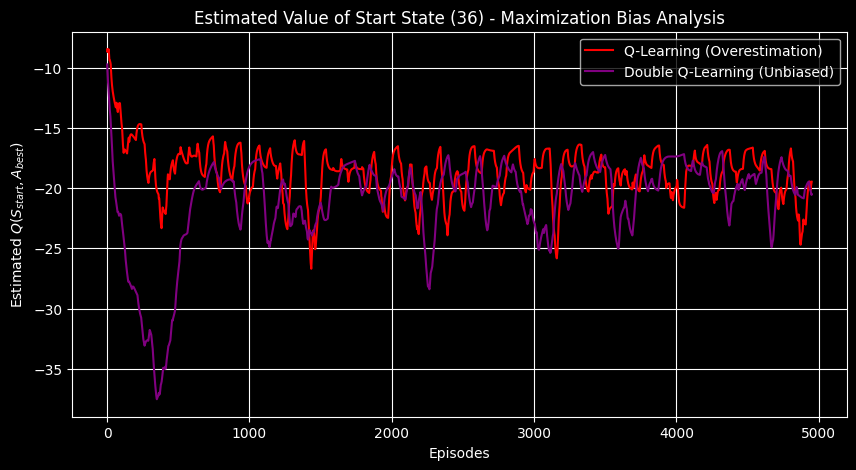

In [13]:
def run_double_q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    Q1 = np.zeros((env.nS, env.nA))
    Q2 = np.zeros((env.nS, env.nA))
    returns = np.zeros(num_episodes)
    # ذخیره تخمین بهترین اکشن در وضعیت شروع (وضعیت 36)
    q_start_max_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        s, _ = env.reset()
        G = 0
        done, truncated = False, False

        while not (done or truncated):
            # انتخاب اکشن با استفاده از مجموع Q1 و Q2
            Q_sum = Q1[s] + Q2[s]
            if np.random.rand() < epsilon:
                a = np.random.choice(env.nA)
            else:
                best_actions = np.argwhere(Q_sum == np.amax(Q_sum)).flatten()
                a = np.random.choice(best_actions)

            next_s, r, done, truncated, _ = env.step(a)
            G += r

            # به‌روزرسانی تصادفی Q1 یا Q2
            if np.random.rand() < 0.5:
                # Q1 انتخاب اکشن را انجام میدهد، Q2 ارزش آن را ارزیابی میکند
                best_next_a = np.random.choice(np.argwhere(Q1[next_s] == np.amax(Q1[next_s])).flatten())
                target = r + gamma * Q2[next_s, best_next_a] * (not done)
                Q1[s, a] += alpha * (target - Q1[s, a])
            else:
                # برعکس
                best_next_a = np.random.choice(np.argwhere(Q2[next_s] == np.amax(Q2[next_s])).flatten())
                target = r + gamma * Q1[next_s, best_next_a] * (not done)
                Q2[s, a] += alpha * (target - Q2[s, a])

            s = next_s

        returns[ep] = G
        # میانگین تخمین بهترین ارزش وضعیت شروع را ذخیره میکنیم
        q_start_max_history[ep] = np.max((Q1[36] + Q2[36]) / 2.0)

    return returns, q_start_max_history

print("Running Double Q-Learning...")
returns_dq, q_start_dq = run_double_q_learning(env, num_episodes)

# برای مقایسه، باید Q-Learning معمولی را هم با ذخیره ارزش الوضعیت شروع اجرا کنیم
def run_q_learning_with_history(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    Q = np.zeros((env.nS, env.nA))
    q_start_max_history = np.zeros(num_episodes)

    for ep in range(num_episodes):
        s, _ = env.reset()
        a = epsilon_greedy_action(Q, s, epsilon)
        done, truncated = False, False
        while not (done or truncated):
            next_s, r, done, truncated, _ = env.step(a)
            target = r + gamma * np.max(Q[next_s]) * (not done)
            Q[s, a] += alpha * (target - Q[s, a])
            a = epsilon_greedy_action(Q, next_s, epsilon)
            s = next_s
        q_start_max_history[ep] = np.max(Q[36])
    return q_start_max_history

print("Running Q-Learning for State 36 history...")
q_start_q = run_q_learning_with_history(env, num_episodes)

# --- رسم نمودار سوگیری بیشینه‌سازی (Maximization Bias) ---
plt.figure(figsize=(10, 5))
# با استفاده از میانگین متحرک برای خوانایی بهتر نمودار
window = 50
plt.plot(np.convolve(q_start_q, np.ones(window)/window, mode='valid'), label='Q-Learning (Overestimation)', color='red')
plt.plot(np.convolve(q_start_dq, np.ones(window)/window, mode='valid'), label='Double Q-Learning (Unbiased)', color='purple')
plt.title("Estimated Value of Start State (36) - Maximization Bias Analysis")
plt.xlabel("Episodes")
plt.ylabel(r"Estimated $Q(S_{start}, A_{best})$")
plt.legend()
plt.grid(True)
plt.show()

Drawing Visual Grid for SARSA...


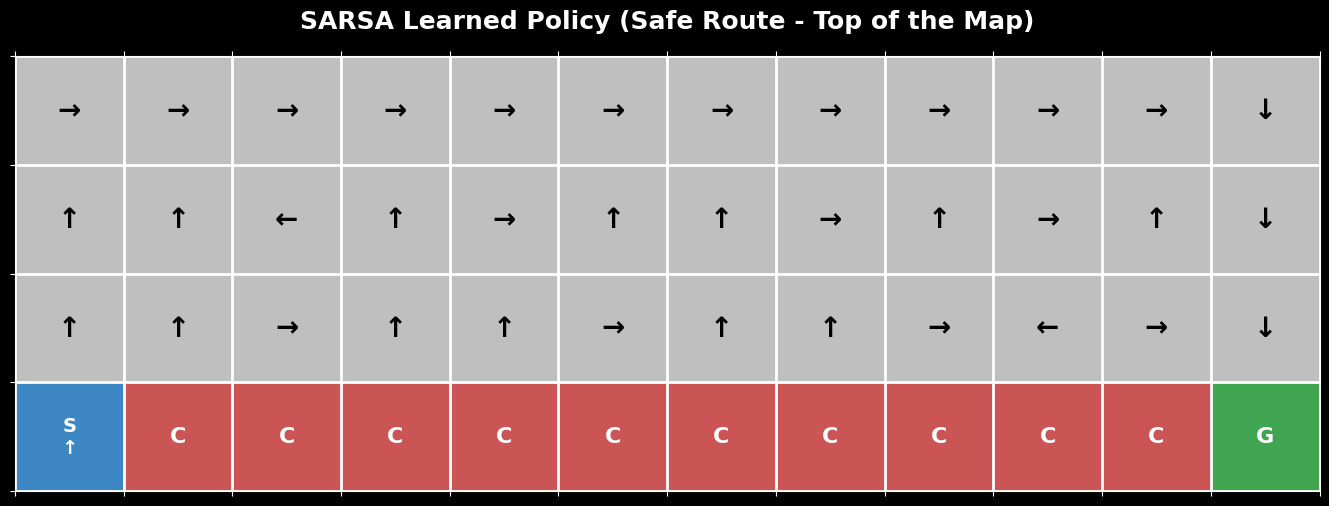

Drawing Visual Grid for Q-Learning...


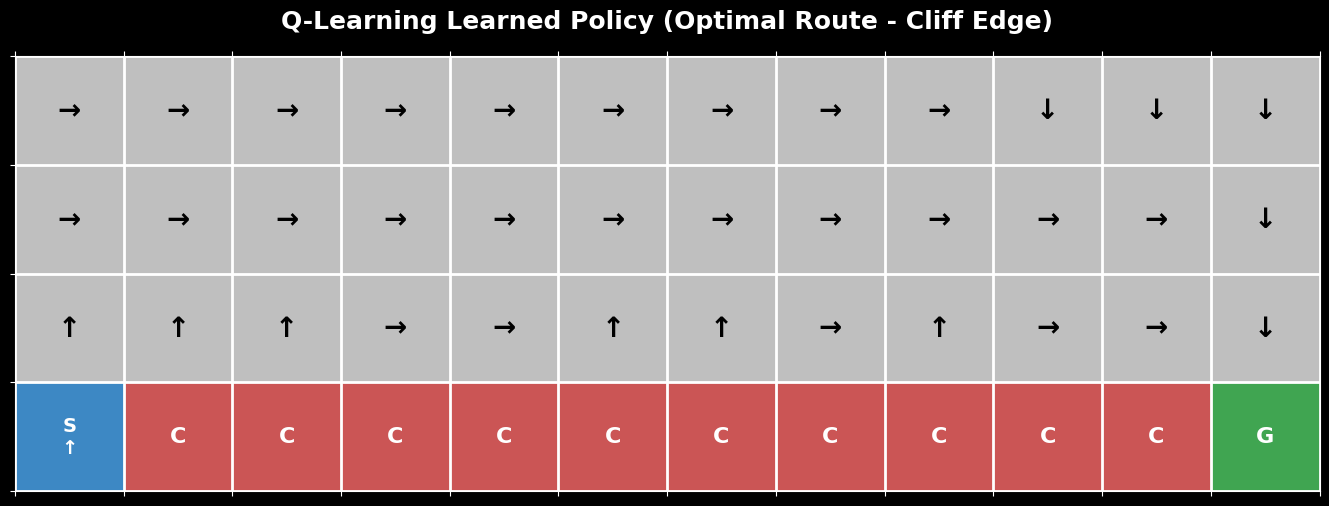

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def draw_beautiful_policy_grid(Q, title):
    """رسم گرافیکی محیط و سیاست (مسیر حرکت) استخراج شده از جدول Q"""
    grid_shape = (4, 12)

    # استخراج بهترین عمل در هر وضعیت
    policy = np.argmax(Q, axis=1)

    # ساخت نقشه رنگی محیط
    # 0: مسیرهای عادی (سفید)
    # 1: صخره (قرمز)
    # 2: نقطه شروع (آبی)
    # 3: هدف (سبز)
    map_grid = np.zeros(grid_shape)
    map_grid[3, 1:11] = 1  # صخره
    map_grid[3, 0] = 2     # شروع
    map_grid[3, 11] = 3    # هدف

    # تعریف رنگ‌ها
    cmap = ListedColormap(['#f0f0f0', '#ff6b6b', '#4dabf7', '#51cf66'])

    fig, ax = plt.subplots(figsize=(14, 5))
    cax = ax.matshow(map_grid, cmap=cmap, alpha=0.8)

    # دیکشنری فلش‌ها برای نمایش جهت حرکت
    arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}

    # رسم فلش‌ها روی خانه‌های شبکه
    for s in range(48):
        r, c = s // 12, s % 12

        # روی صخره و هدف فلشی نمی‌کشیم
        if map_grid[r, c] == 1:
            ax.text(c, r, 'C', va='center', ha='center', color='white', fontsize=16, fontweight='bold')
        elif map_grid[r, c] == 3:
            ax.text(c, r, 'G', va='center', ha='center', color='white', fontsize=16, fontweight='bold')
        elif map_grid[r, c] == 2:
            act = policy[s]
            ax.text(c, r, f'S\n{arrows[act]}', va='center', ha='center', color='white', fontsize=14, fontweight='bold')
        else:
            act = policy[s]
            ax.text(c, r, arrows[act], va='center', ha='center', color='black', fontsize=20, fontweight='bold')

    # تنظیمات ظاهری
    plt.title(title, fontsize=18, pad=20, fontweight='bold')
    plt.xticks(np.arange(-0.5, 12, 1), [])
    plt.yticks(np.arange(-0.5, 4, 1), [])
    plt.grid(color='white', linestyle='-', linewidth=2)
    plt.tight_layout()
    plt.show()

# این دو خط را در انتهای کدهای قبلی خود اجرا کنید
print("Drawing Visual Grid for SARSA...")
draw_beautiful_policy_grid(Q_sarsa, "SARSA Learned Policy (Safe Route - Top of the Map)")

print("Drawing Visual Grid for Q-Learning...")
draw_beautiful_policy_grid(Q_q, "Q-Learning Learned Policy (Optimal Route - Cliff Edge)")

# Temp0(ByMe)

***Cell 0 — پیش‌نیازها***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from dataclasses import dataclass
import math
import random

***Cell 1 — برای بازتولیدپذیری***

In [2]:
def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

***Cell 2 — Stochastic Cliff Walking Env***

In [4]:
class StochasticCliffWalkingEnv:
    """
    4x12 stochastic cliff walking.
    States are numbered row-major from top-left: 0..47
    Start = 36, Goal = 47, Cliff = 37..46
    Actions: 0=up, 1=right, 2=down, 3=left
    """
    def __init__(self, slip_rate=0.1, max_length=200, gamma=0.99):
        self.n_rows = 4
        self.n_cols = 12
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4
        self.slip_rate = slip_rate
        self.max_length = max_length
        self.gamma = gamma

        self.start_state = 36
        self.goal_state = 47
        self.cliff_states = set(range(37, 47))

        self.state = self.start_state
        self.t = 0

        # Base deterministic action mapping
        self.action_to_delta = {
            0: (-1, 0),  # up
            1: (0, 1),   # right
            2: (1, 0),   # down
            3: (0, -1),  # left
        }
        self.perpendicular = {
            0: [3, 1],   # left, right
            1: [0, 2],   # up, down
            2: [3, 1],   # left, right
            3: [0, 2],   # up, down
        }

    def _to_rc(self, s):
        return divmod(s, self.n_cols)

    def _to_s(self, r, c):
        return r * self.n_cols + c

    def reset(self, state=None):
        self.state = self.start_state if state is None else state
        self.t = 0
        return self.state

    def _move(self, s, a):
        r, c = self._to_rc(s)
        dr, dc = self.action_to_delta[a]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.n_rows and 0 <= nc < self.n_cols):
            return s
        return self._to_s(nr, nc)

    def step(self, a):
        """
        Returns: next_state, reward, done, extra
        extra = dict(cliff=False/True, timeout=False/True, actual_action=...)
        """
        self.t += 1

        # stochastic action execution
        u = np.random.rand()
        if u < 1.0 - self.slip_rate:
            actual_a = a
        else:
            actual_a = np.random.choice(self.perpendicular[a])

        ns = self._move(self.state, actual_a)
        reward = -1
        done = False
        extra = {"cliff": False, "timeout": False, "actual_action": actual_a}

        # cliff handling
        if ns in self.cliff_states:
            reward = -100
            ns = self.start_state
            extra["cliff"] = True

        # goal handling
        if ns == self.goal_state:
            reward = 0
            done = True

        # timeout
        if self.t >= self.max_length and not done:
            reward = -50
            done = True
            extra["timeout"] = True

        self.state = ns
        return ns, reward, done, extra

    def render(self, agent_state=None):
        """
        Text render suitable for notebook/console.
        """
        symbols = []
        for r in range(self.n_rows):
            row = []
            for c in range(self.n_cols):
                s = self._to_s(r, c)
                if s == self.start_state:
                    ch = "S"
                elif s == self.goal_state:
                    ch = "G"
                elif s in self.cliff_states:
                    ch = "C"
                else:
                    ch = "."
                row.append(ch)
            symbols.append(row)

        if agent_state is not None:
            r, c = self._to_rc(agent_state)
            symbols[r][c] = "A"

        for row in symbols:
            print(" ".join(row))
        print()

***Cell 3 — توابع کمکی برای سیاست و نمایش***

In [5]:
ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def greedy_action(Q, s):
    return int(np.argmax(Q[s]))

def epsilon_greedy_probs(Q_s, epsilon, n_actions=4):
    probs = np.ones(n_actions) * (epsilon / n_actions)
    best_a = int(np.argmax(Q_s))
    probs[best_a] += (1.0 - epsilon)
    return probs

def epsilon_greedy_action(Q, s, epsilon):
    probs = epsilon_greedy_probs(Q[s], epsilon, Q.shape[1])
    return int(np.random.choice(len(probs), p=probs))

def random_uniform_action(n_actions=4):
    return int(np.random.randint(n_actions))

def policy_from_Q_epsilon_greedy(Q, epsilon):
    def pi(s):
        return epsilon_greedy_probs(Q[s], epsilon, Q.shape[1])
    return pi

def greedy_policy_from_Q(Q):
    def pi(s):
        probs = np.zeros(Q.shape[1])
        probs[np.argmax(Q[s])] = 1.0
        return probs
    return pi

def print_policy_grid(policy, env: StochasticCliffWalkingEnv):
    """
    policy: function s -> probs over actions
    """
    grid = []
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                row.append("S")
            elif s == env.goal_state:
                row.append("G")
            elif s in env.cliff_states:
                row.append("C")
            else:
                a = int(np.argmax(policy(s)))
                row.append(ARROWS[a])
        grid.append(row)
    for row in grid:
        print(" ".join(f"{x:>2}" for x in row))
    print()

def rollout_greedy_path(env, Q, max_steps=200):
    s = env.reset()
    path = [s]
    rewards = []
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        ns, r, done, extra = env.step(a)
        path.append(ns)
        rewards.append(r)
        s = ns
        if done:
            break
    return path, rewards

def render_path_on_grid(env, path):
    grid = []
    path_set = set(path)
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                ch = "S"
            elif s == env.goal_state:
                ch = "G"
            elif s in env.cliff_states:
                ch = "C"
            elif s in path_set:
                ch = "*"
            else:
                ch = "."
            row.append(ch)
        grid.append(row)
    for row in grid:
        print(" ".join(row))
    print()

***Cell 4 — تابع تولید اپیزود***

In [6]:
def episode_generate(pi, env, render=False, start_state=None):
    """
    pi: function s -> probability distribution over actions
    returns: rewards, actions, states
    """
    states = []
    actions = []
    rewards = []

    s = env.reset(start_state)
    states.append(s)

    if render:
        print("Initial state:")
        env.render(agent_state=s)

    done = False
    while not done:
        probs = pi(s)
        a = int(np.random.choice(len(probs), p=probs))
        ns, r, done, extra = env.step(a)

        actions.append(a)
        rewards.append(r)
        states.append(ns)

        if render:
            print(f"s={s}, a={a}, r={r}, ns={ns}, extra={extra}")
            env.render(agent_state=ns)

        s = ns

    return rewards, actions, states

***Cell 5 — Monte Carlo کنترل First-Visit با سیاست soft-ε***

In [7]:
def first_visit_mc_control(env, num_episodes=50000, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    nS, nA = env.n_states, env.n_actions
    Q = np.zeros((nS, nA), dtype=np.float64)
    returns_sum = np.zeros((nS, nA), dtype=np.float64)
    returns_count = np.zeros((nS, nA), dtype=np.float64)

    episode_returns = []

    for ep in range(num_episodes):
        pi = policy_from_Q_epsilon_greedy(Q, epsilon)
        rewards, actions, states = episode_generate(pi, env, render=False)

        G = 0.0
        visited_sa = set()
        ep_return = 0.0

        for t in range(len(actions)-1, -1, -1):
            s = states[t]
            a = actions[t]
            r = rewards[t]
            ep_return += r
            G = gamma * G + r

            if (s, a) not in visited_sa:
                visited_sa.add((s, a))
                returns_sum[s, a] += G
                returns_count[s, a] += 1.0
                Q[s, a] = returns_sum[s, a] / returns_count[s, a]

        episode_returns.append(ep_return)

    return Q, np.array(episode_returns)

***Cell 6 —  استخراج سیاست نهایی***

In [8]:
def greedy_policy_from_table(Q):
    return lambda s: np.eye(Q.shape[1])[int(np.argmax(Q[s]))]

***Cell 7 — نمونه مسیر سیاست نهایی***

In [9]:
def sample_policy_path(env, Q, epsilon=0.0, max_steps=200):
    s = env.reset()
    path = [s]
    rewards = []
    for _ in range(max_steps):
        if epsilon > 0:
            a = epsilon_greedy_action(Q, s, epsilon)
        else:
            a = int(np.argmax(Q[s]))
        ns, r, done, extra = env.step(a)
        path.append(ns)
        rewards.append(r)
        s = ns
        if done:
            break
    return path, rewards

***Cell 8 — اجرای نمونه  `ε=0.1` و `ε=0.01`***

In [10]:
env = StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)

Q_01, returns_01 = first_visit_mc_control(env, num_episodes=50000, epsilon=0.1, gamma=0.99, seed=1)
Q_001, returns_001 = first_visit_mc_control(env, num_episodes=50000, epsilon=0.01, gamma=0.99, seed=1)

path_01, _ = sample_policy_path(env, Q_01, epsilon=0.0)
path_001, _ = sample_policy_path(env, Q_001, epsilon=0.0)

print("Policy epsilon=0.1")
print_policy_grid(greedy_policy_from_table(Q_01), env)
render_path_on_grid(env, path_01)

print("Policy epsilon=0.01")
print_policy_grid(greedy_policy_from_table(Q_001), env)
render_path_on_grid(env, path_001)

Policy epsilon=0.1
 ↓  ←  →  →  →  →  →  →  →  →  ↓  ↓
 →  →  ↑  ↑  ↑  →  ↑  ←  →  →  →  ↓
 →  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

Policy epsilon=0.01
 →  ←  ↑  ↑  ←  ←  ←  ←  ←  ←  →  →
 ←  ↑  →  ↑  ←  →  →  →  ←  ↓  →  ↑
 ↑  ↑  ←  ←  ↑  ↑  →  ↓  ↓  →  ↑  ↑
 S  C  C  C  C  C  C  C  C  C  C  G

. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G



Cell 9 — اجرای 10 بار مستقل برای `ε=0.1` و رسم میانگین بازده با نوار انحراف معیار

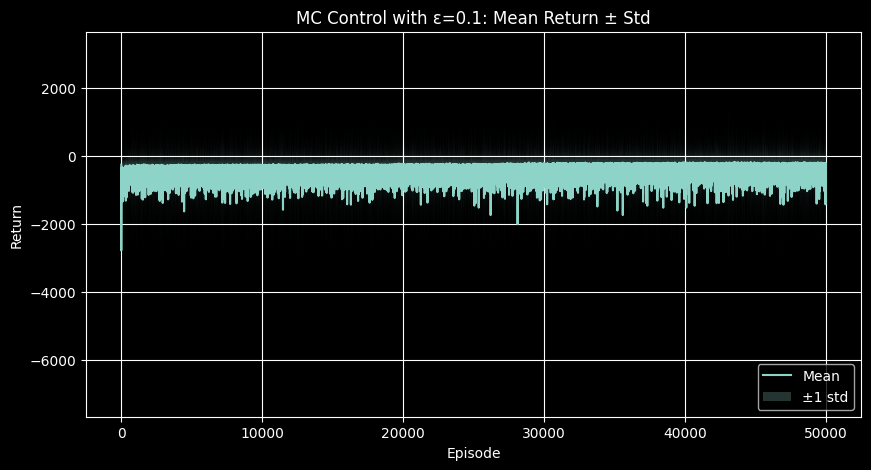

In [11]:
def run_multiple_mc(env_factory, n_runs=10, num_episodes=50000, epsilon=0.1, gamma=0.99):
    all_returns = []
    all_Q = []

    for run in range(n_runs):
        env = env_factory()
        Q, ep_returns = first_visit_mc_control(
            env,
            num_episodes=num_episodes,
            epsilon=epsilon,
            gamma=gamma,
            seed=run + 123
        )
        all_returns.append(ep_returns)
        all_Q.append(Q)

    all_returns = np.array(all_returns)   # [runs, episodes]
    return all_Q, all_returns

def plot_mean_std_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.25, label="±1 std")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

env_factory = lambda: StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)
all_Qs_01, all_returns_01 = run_multiple_mc(env_factory, n_runs=10, num_episodes=50000, epsilon=0.1, gamma=0.99)

plot_mean_std_curve(all_returns_01, title="MC Control with ε=0.1: Mean Return ± Std")

***Cell 10 — پیش‌بینی ارزش با Importance Sampling***

In [12]:
def behavior_policy_uniform(s, n_actions=4):
    return np.ones(n_actions) / n_actions

def target_policy_from_Q_greedy(Q):
    def pi(s):
        probs = np.zeros(Q.shape[1])
        probs[int(np.argmax(Q[s]))] = 1.0
        return probs
    return pi

def generate_episode_from_state(env, behavior_pi, start_state, max_steps=200):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    for _ in range(max_steps):
        probs = behavior_pi(s)
        a = int(np.random.choice(len(probs), p=probs))
        ns, r, done, extra = env.step(a)

        states.append(ns)
        actions.append(a)
        rewards.append(r)

        s = ns
        if done:
            break

    return states, actions, rewards

def ordinary_and_weighted_is_prediction(env, Q_target, start_state, n_episodes=10000, gamma=0.99, seed=42):
    set_seed(seed)
    behavior_pi = lambda s: behavior_policy_uniform(s, env.n_actions)
    target_pi = target_policy_from_Q_greedy(Q_target)

    ordinary_est = 0.0
    weighted_est = 0.0
    ordinary_c = 0.0
    weighted_c = 0.0

    curve_ordinary = []
    curve_weighted = []

    for ep in range(n_episodes):
        states, actions, rewards = generate_episode_from_state(env, behavior_pi, start_state, max_steps=env.max_length)

        G = 0.0
        rho = 1.0

        for t in range(len(actions)-1, -1, -1):
            s_t = states[t]
            a_t = actions[t]
            r_t = rewards[t]
            G = gamma * G + r_t

            b = behavior_pi(s_t)[a_t]
            p = target_pi(s_t)[a_t]
            if b == 0:
                rho = 0.0
            else:
                rho *= (p / b)

        ordinary_c += 1.0
        ordinary_est += (rho * G - ordinary_est) / ordinary_c

        weighted_c += rho
        if weighted_c != 0:
            weighted_est += (rho / weighted_c) * (G - weighted_est)

        curve_ordinary.append(ordinary_est)
        curve_weighted.append(weighted_est)

    return np.array(curve_ordinary), np.array(curve_weighted)

***Cell 11 —  اجرای سه حالت***

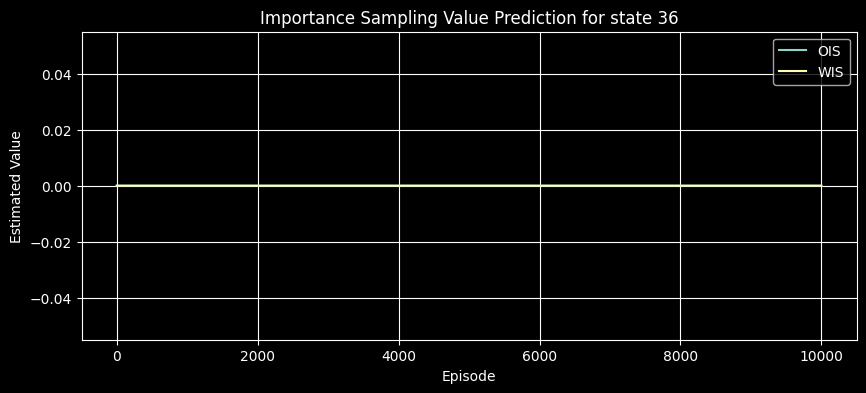

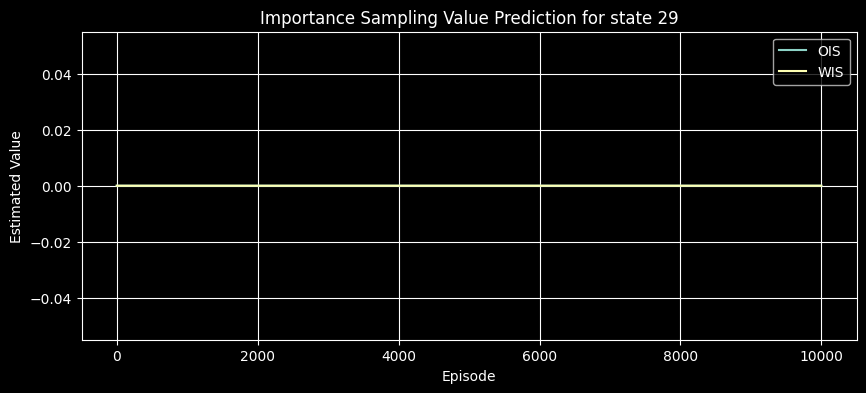

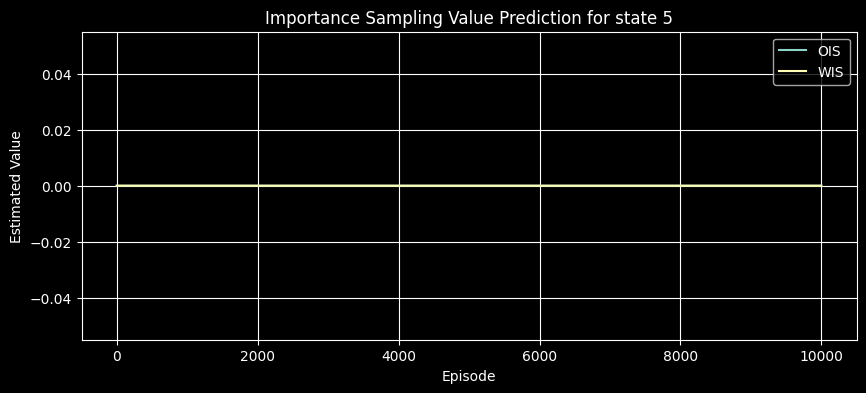

In [13]:
Q_target = Q_01  # یا Q_001

states_to_eval = [36, 29, 5]
results_is = {}

for s in states_to_eval:
    o_curve, w_curve = ordinary_and_weighted_is_prediction(
        StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99),
        Q_target,
        start_state=s,
        n_episodes=10000,
        gamma=0.99,
        seed=100 + s
    )
    results_is[s] = (o_curve, w_curve)

    plt.figure(figsize=(10, 4))
    plt.plot(o_curve, label="OIS")
    plt.plot(w_curve, label="WIS")
    plt.title(f"Importance Sampling Value Prediction for state {s}")
    plt.xlabel("Episode")
    plt.ylabel("Estimated Value")
    plt.legend()
    plt.grid(True)
    plt.show()

***Cell 12 — محاسبه‌ی ارزش واقعی با Policy Evaluation***

In [14]:
def build_transition_model(env: StochasticCliffWalkingEnv):
    """
    P[s][a] = list of (prob, next_state, reward, done)
    This is the model for the base 48-state MDP (without explicit time dimension).
    """
    P = {s: {a: [] for a in range(env.n_actions)} for s in range(env.n_states)}

    for s in range(env.n_states):
        for a in range(env.n_actions):
            if s == env.goal_state:
                P[s][a].append((1.0, s, 0.0, True))
                continue

            # intended + slip to perpendicular actions
            probs = [(a, 1.0 - env.slip_rate)] + [(pa, env.slip_rate / 2.0) for pa in env.perpendicular[a]]

            trans = defaultdict(lambda: [0.0, 0.0, False])  # next_state -> [prob, reward_sum, done_or]

            for real_a, p in probs:
                ns = env._move(s, real_a)
                r = -1
                done = False

                if ns in env.cliff_states:
                    r = -100
                    ns = env.start_state

                if ns == env.goal_state:
                    r = 0
                    done = True

                trans[ns][0] += p
                trans[ns][1] += p * r
                trans[ns][2] = trans[ns][2] or done

            for ns, (p, rsum, done) in trans.items():
                avg_r = rsum / p if p > 0 else 0.0
                P[s][a].append((p, ns, avg_r, done))
    return P

***Cell 13 —  ارزیابی سیاست یکنواخت***

In [15]:
def policy_evaluation_iterative(P, policy, gamma=0.99, theta=1e-10, n_states=48, n_actions=4):
    V = np.zeros(n_states, dtype=np.float64)
    while True:
        delta = 0.0
        for s in range(n_states):
            v_old = V[s]
            v_new = 0.0
            for a in range(n_actions):
                pi_sa = policy(s)[a]
                if pi_sa == 0:
                    continue
                for p, ns, r, done in P[s][a]:
                    v_new += pi_sa * p * (r + (0.0 if done else gamma * V[ns]))
            V[s] = v_new
            delta = max(delta, abs(v_old - V[s]))
        if delta < theta:
            break
    return V

In [16]:
env = StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)
P = build_transition_model(env)
random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
V_true = policy_evaluation_iterative(P, random_policy, gamma=0.99, n_states=env.n_states, n_actions=env.n_actions)

***Cell 14 — Every-Visit MC و TD(0)***

In [17]:
def every_visit_mc_prediction(env, policy, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    counts = np.zeros(env.n_states, dtype=np.float64)

    traj_values = {36: [], 29: [], 5: []}
    rmse_curve = []

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode_from_state(env, policy, env.start_state, max_steps=env.max_length)

        G = 0.0
        returns = []

        for t in range(len(actions)-1, -1, -1):
            G = gamma * G + rewards[t]
            returns.append(G)
        returns = returns[::-1]

        for t, s in enumerate(states[:-1]):
            counts[s] += 1.0
            V[s] += (returns[t] - V[s]) / counts[s]

        for key in traj_values:
            traj_values[key].append(V[key])
        rmse_curve.append(np.sqrt(np.mean((V - V_true)**2)))

    return V, np.array(rmse_curve), traj_values

In [18]:
def td0_prediction(env, policy, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)

    traj_values = {36: [], 29: [], 5: []}
    rmse_curve = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False

        while not done:
            a = int(np.random.choice(env.n_actions, p=policy(s)))
            ns, r, done, extra = env.step(a)
            target = r + (0.0 if done else gamma * V[ns])
            V[s] += alpha * (target - V[s])
            s = ns

        for key in traj_values:
            traj_values[key].append(V[key])
        rmse_curve.append(np.sqrt(np.mean((V - V_true)**2)))

    return V, np.array(rmse_curve), traj_values

***Cell 15 — پیش‌بینی ارزش با Importance Sampling***

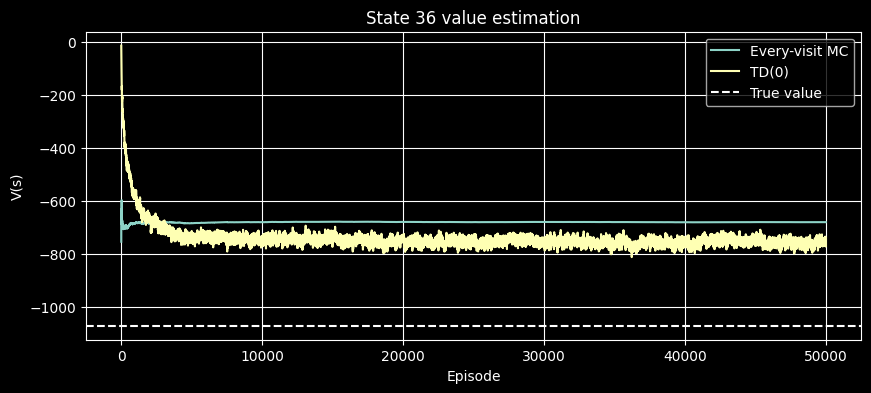

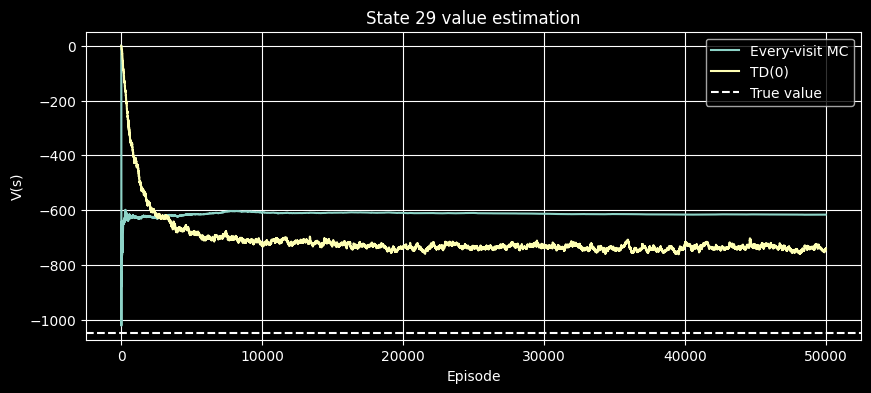

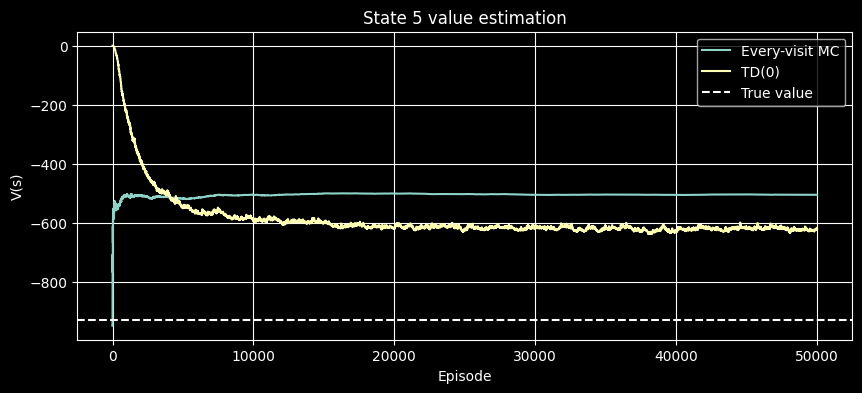

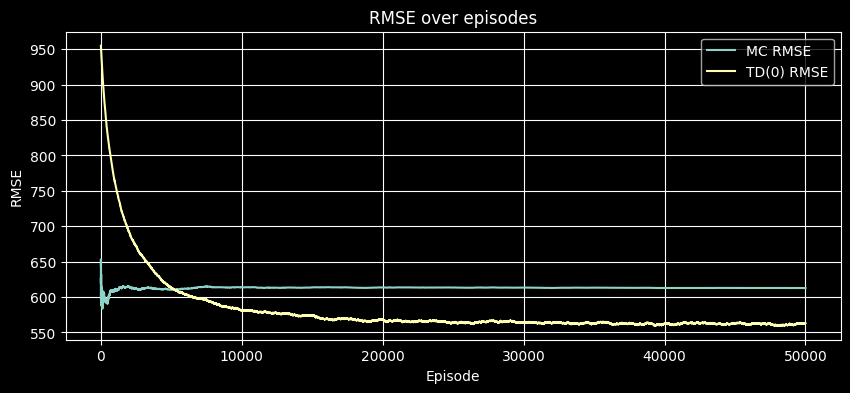

In [20]:
V_mc, rmse_mc, traj_mc = every_visit_mc_prediction(env, random_policy, num_episodes=50000, gamma=0.99, seed=1)
V_td, rmse_td, traj_td = td0_prediction(env, random_policy, alpha=0.01, num_episodes=50000, gamma=0.99, seed=1)

for s in [36, 29, 5]:
    plt.figure(figsize=(10, 4))
    plt.plot(traj_mc[s], label="Every-visit MC")
    plt.plot(traj_td[s], label="TD(0)")
    plt.axhline(V_true[s], linestyle="--", label="True value")
    plt.title(f"State {s} value estimation")
    plt.xlabel("Episode")
    plt.ylabel("V(s)")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.figure(figsize=(10, 4))
plt.plot(rmse_mc, label="MC RMSE")
plt.plot(rmse_td, label="TD(0) RMSE")
plt.title("RMSE over episodes")
plt.xlabel("Episode")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

***Cell 16 — TD step-n***

In [19]:
def n_step_td_prediction(env, policy, n=1, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    rmse_curve = []

    for ep in range(num_episodes):
        states = [env.reset()]
        rewards = [0.0]
        T = math.inf
        t = 0

        while True:
            if t < T:
                s_t = states[t]
                a_t = int(np.random.choice(env.n_actions, p=policy(s_t)))
                ns, r, done, extra = env.step(a_t)
                states.append(ns)
                rewards.append(r)
                if done:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = min(tau + n, T)
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                if tau + n < T:
                    G += (gamma ** n) * V[states[tau + n]]

                s_tau = states[tau]
                if s_tau != env.goal_state:
                    V[s_tau] += alpha * (G - V[s_tau])

            if tau == T - 1:
                break
            t += 1

        rmse_curve.append(np.sqrt(np.mean((V - V_true)**2)))

    return V, np.array(rmse_curve)

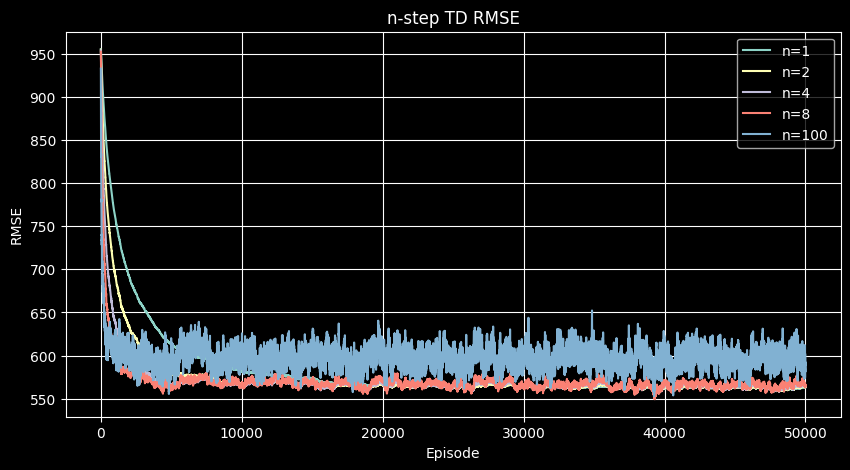

In [21]:
# اجرای چند n

n_values = [1, 2, 4, 8, 100]
rmse_by_n = {}

for n in n_values:
    _, rmse_curve = n_step_td_prediction(env, random_policy, n=n, alpha=0.01, num_episodes=50000, gamma=0.99, seed=1)
    rmse_by_n[n] = rmse_curve

plt.figure(figsize=(10, 5))
for n in n_values:
    plt.plot(rmse_by_n[n], label=f"n={n}")
plt.title("n-step TD RMSE")
plt.xlabel("Episode")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

***Cell 17 —  SARSA، Q-Learning، Expected SARSA و Double Q-Learning***

In [22]:
def sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = []
    start_values = []

    for ep in range(num_episodes):
        s = env.reset()
        a = epsilon_greedy_action(Q, s, epsilon)
        done = False
        ep_return = 0.0

        while not done:
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                target = r
                Q[s, a] += alpha * (target - Q[s, a])
                break
            na = epsilon_greedy_action(Q, ns, epsilon)
            target = r + gamma * Q[ns, na]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = ns, na

        returns.append(ep_return)
        start_values.append(np.max(Q[env.start_state]))
    return Q, np.array(returns), np.array(start_values)

In [23]:
def q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = []
    start_values = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = epsilon_greedy_action(Q, s, epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            target = r if done else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns.append(ep_return)
        start_values.append(np.max(Q[env.start_state]))
    return Q, np.array(returns), np.array(start_values)

In [24]:
def expected_sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = []
    start_values = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = epsilon_greedy_action(Q, s, epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if done:
                target = r
            else:
                probs = epsilon_greedy_probs(Q[ns], epsilon, env.n_actions)
                expected_q = np.sum(probs * Q[ns])
                target = r + gamma * expected_q

            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns.append(ep_return)
        start_values.append(np.max(Q[env.start_state]))
    return Q, np.array(returns), np.array(start_values)

In [25]:
def double_q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q1 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    Q2 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = []
    start_values = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            Qsum = Q1 + Q2
            a = epsilon_greedy_action(Qsum, s, epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if np.random.rand() < 0.5:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q1[ns]))
                    target = r + gamma * Q2[ns, a_star]
                Q1[s, a] += alpha * (target - Q1[s, a])
            else:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q2[ns]))
                    target = r + gamma * Q1[ns, a_star]
                Q2[s, a] += alpha * (target - Q2[s, a])

            s = ns

        returns.append(ep_return)
        start_values.append(np.max((Q1[env.start_state] + Q2[env.start_state]) / 2.0))
    return (Q1, Q2), np.array(returns), np.array(start_values)

***Cell 18 —  اجرای 10 بار و رسم بازده با نوار اطمینان***

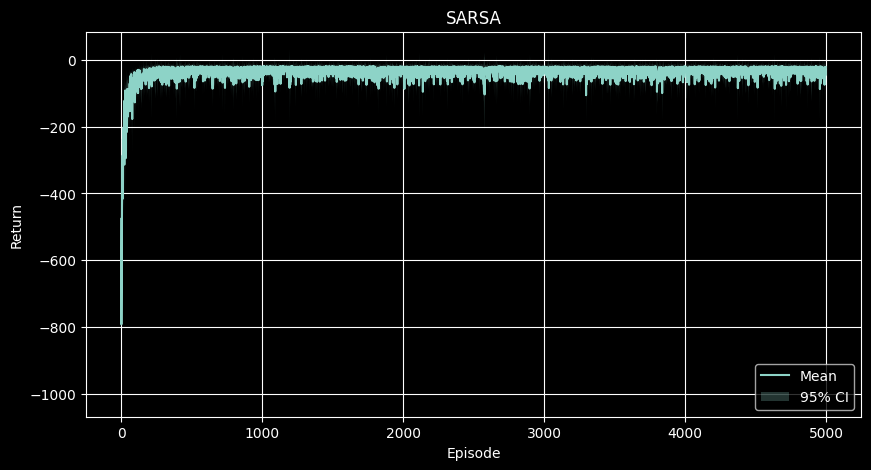

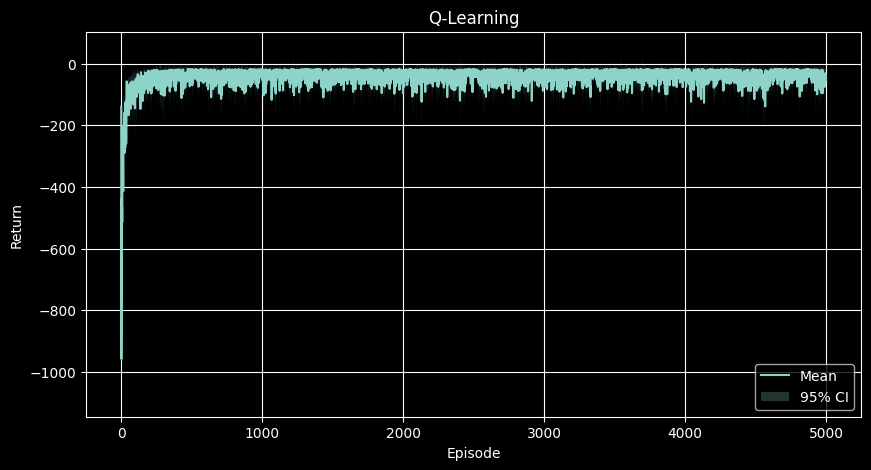

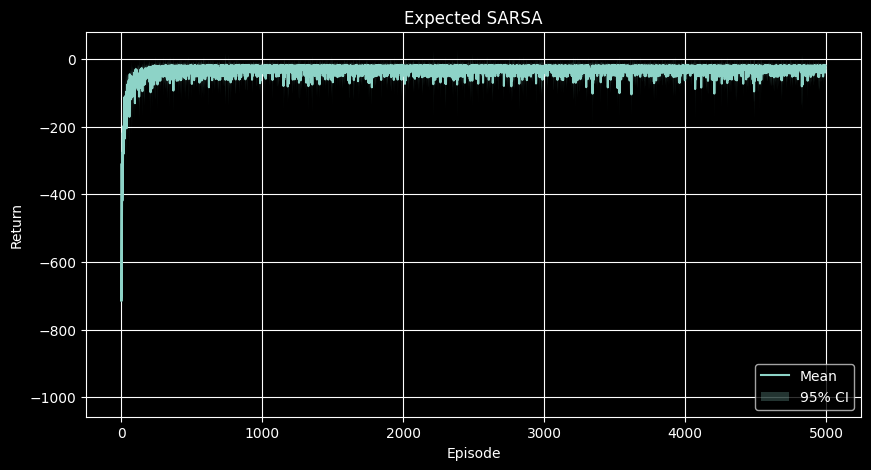

SARSA policy:
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  →  →  ↑  →  ↑  →  ↑  ↑  ↑  →  ↓
 ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Q-Learning policy:
 →  →  →  →  →  →  →  →  →  →  →  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 →  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Expected SARSA policy:
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G



In [26]:
def run_control_algo(algo_fn, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    all_returns = []
    all_start_values = []
    final_policies = []

    for run in range(n_runs):
        env = env_factory()
        out = algo_fn(env, num_episodes=num_episodes, alpha=alpha, epsilon=epsilon, gamma=gamma, seed=run + 10)
        if algo_fn.__name__ == "double_q_learning":
            (Q1, Q2), returns, start_vals = out
            final_Q = (Q1 + Q2) / 2.0
        else:
            Q, returns, start_vals = out
            final_Q = Q

        all_returns.append(returns)
        all_start_values.append(start_vals)
        final_policies.append(final_Q)

    return np.array(all_returns), np.array(all_start_values), final_policies

def plot_mean_ci_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])

    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - ci, mean + ci, alpha=0.25, label="95% CI")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

env_factory = lambda: StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)

sarsa_returns, sarsa_start_vals, sarsa_Qs = run_control_algo(sarsa, env_factory)
q_returns, q_start_vals, q_Qs = run_control_algo(q_learning, env_factory)
exp_returns, exp_start_vals, exp_Qs = run_control_algo(expected_sarsa, env_factory)

plot_mean_ci_curve(sarsa_returns, title="SARSA")
plot_mean_ci_curve(q_returns, title="Q-Learning")
plot_mean_ci_curve(exp_returns, title="Expected SARSA")

# نمایش سیاست نهایی

def extract_policy_from_Q(Q):
    return lambda s: np.eye(Q.shape[1])[int(np.argmax(Q[s]))]

best_sarsa_Q = sarsa_Qs[-1]
best_q_Q = q_Qs[-1]
best_exp_Q = exp_Qs[-1]

print("SARSA policy:")
print_policy_grid(extract_policy_from_Q(best_sarsa_Q), env)

print("Q-Learning policy:")
print_policy_grid(extract_policy_from_Q(best_q_Q), env)

print("Expected SARSA policy:")
print_policy_grid(extract_policy_from_Q(best_exp_Q), env)

***Cell 19 — Double Q-Learning و Maximum Bias***

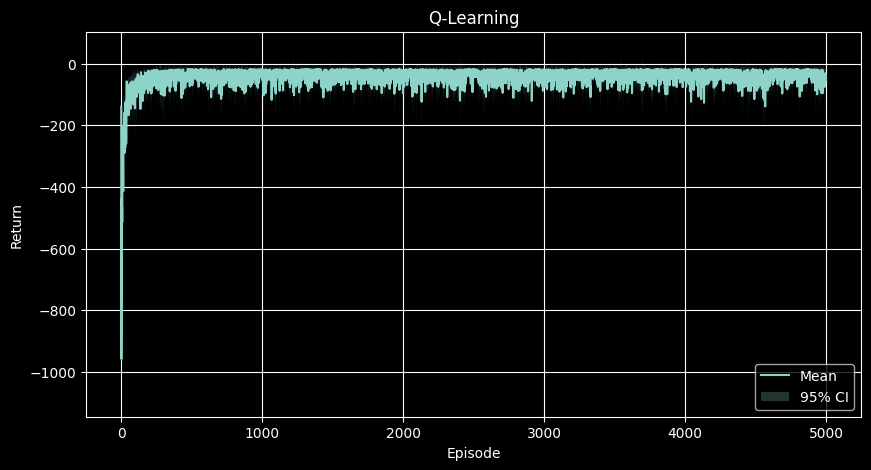

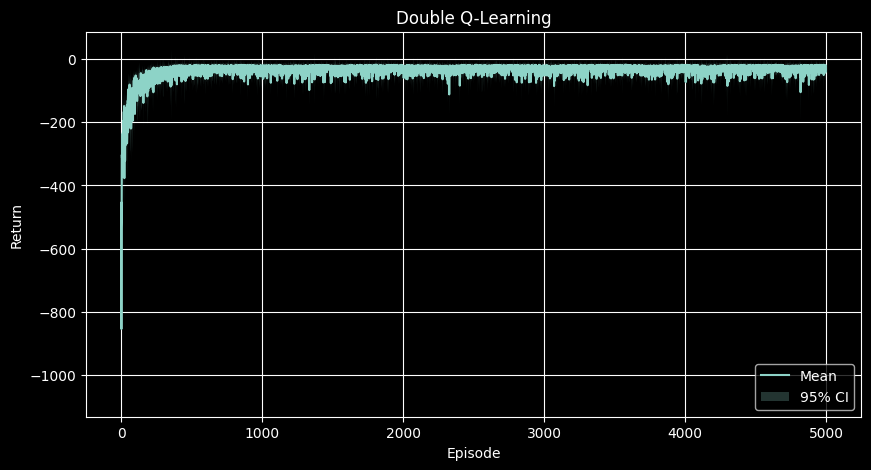

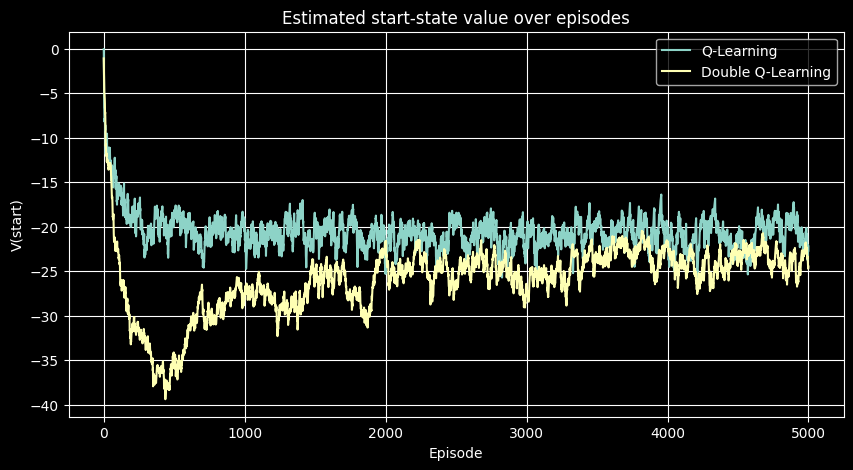

In [27]:
double_returns, double_start_vals, double_Qs = run_control_algo(double_q_learning, env_factory)

plot_mean_ci_curve(q_returns, title="Q-Learning")
plot_mean_ci_curve(double_returns, title="Double Q-Learning")

plt.figure(figsize=(10, 5))
plt.plot(q_start_vals.mean(axis=0), label="Q-Learning")
plt.plot(double_start_vals.mean(axis=0), label="Double Q-Learning")
plt.title("Estimated start-state value over episodes")
plt.xlabel("Episode")
plt.ylabel("V(start)")
plt.legend()
plt.grid(True)
plt.show()

# Temp1(Optimized Colab)

In [1]:
"""
Optimized Colab for Stochastic Cliff Walking

Focus:
- fast environment stepping
- fast epsilon-greedy action selection
- reduced Python overhead for MC/TD/control algorithms
- safe defaults for sanity checks; increase episode counts to assignment values for final runs
"""

import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)


# -----------------------------
# Environment
# -----------------------------
class StochasticCliffWalkingEnv:
    """
    4x12 stochastic cliff walking.
    States are numbered row-major from top-left: 0..47
    Start = 36, Goal = 47, Cliff = 37..46
    Actions: 0=up, 1=right, 2=down, 3=left
    """
    def __init__(self, slip_rate=0.1, max_length=200, gamma=0.99):
        self.n_rows = 4
        self.n_cols = 12
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4
        self.slip_rate = float(slip_rate)
        self.max_length = int(max_length)
        self.gamma = float(gamma)

        self.start_state = 36
        self.goal_state = 47
        self.cliff_states = set(range(37, 47))

        self.state = self.start_state
        self.t = 0

        self.action_to_delta = {
            0: (-1, 0),  # up
            1: (0, 1),   # right
            2: (1, 0),   # down
            3: (0, -1),  # left
        }
        self.perpendicular = {
            0: [3, 1],
            1: [0, 2],
            2: [3, 1],
            3: [0, 2],
        }

        # Precompute transitions: next_state/reward/done for the 3 stochastic branches
        self.branch_action = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.next_state = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.reward = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)
        self.done = np.empty((self.n_states, self.n_actions, 3), dtype=np.bool_)
        self.branch_prob = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)

        self._precompute()

    def _to_rc(self, s):
        return divmod(int(s), self.n_cols)

    def _to_s(self, r, c):
        return r * self.n_cols + c

    def _move(self, s, a):
        r, c = self._to_rc(s)
        dr, dc = self.action_to_delta[int(a)]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.n_rows and 0 <= nc < self.n_cols):
            return int(s)
        return self._to_s(nr, nc)

    def _precompute(self):
        p_main = 1.0 - self.slip_rate
        p_slip = self.slip_rate / 2.0

        for s in range(self.n_states):
            for a in range(self.n_actions):
                branches = [a, *self.perpendicular[a]]
                probs = [p_main, p_slip, p_slip]
                for k, (ra, p) in enumerate(zip(branches, probs)):
                    self.branch_action[s, a, k] = ra
                    self.branch_prob[s, a, k] = p

                    if s == self.goal_state:
                        ns, r, d = self.goal_state, 0.0, True
                    else:
                        ns = self._move(s, ra)
                        r, d = -1.0, False
                        if ns in self.cliff_states:
                            ns, r, d = self.start_state, -100.0, False
                        elif ns == self.goal_state:
                            r, d = 0.0, True

                    self.next_state[s, a, k] = ns
                    self.reward[s, a, k] = r
                    self.done[s, a, k] = d

    def reset(self, state=None):
        self.state = self.start_state if state is None else int(state)
        self.t = 0
        return self.state

    def step(self, a):
        self.t += 1
        a = int(a)

        u = np.random.rand()
        p0 = self.branch_prob[self.state, a, 0]
        p1 = p0 + self.branch_prob[self.state, a, 1]

        if u < p0:
            k = 0
        elif u < p1:
            k = 1
        else:
            k = 2

        ns = int(self.next_state[self.state, a, k])
        r = float(self.reward[self.state, a, k])
        done = bool(self.done[self.state, a, k])
        extra = {
            "actual_action": int(self.branch_action[self.state, a, k]),
            "cliff": (r == -100.0),
            "timeout": False,
        }

        if self.t >= self.max_length and not done:
            r = -50.0
            done = True
            extra["timeout"] = True

        self.state = ns
        return ns, r, done, extra

    def render(self, agent_state=None):
        grid = []
        for r in range(self.n_rows):
            row = []
            for c in range(self.n_cols):
                s = self._to_s(r, c)
                if s == self.start_state:
                    ch = "S"
                elif s == self.goal_state:
                    ch = "G"
                elif s in self.cliff_states:
                    ch = "C"
                else:
                    ch = "."
                row.append(ch)
            grid.append(row)

        if agent_state is not None:
            rr, cc = self._to_rc(agent_state)
            grid[rr][cc] = "A"

        for row in grid:
            print(" ".join(row))
        print()


# -----------------------------
# Helpers
# -----------------------------
ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}


def eps_greedy_action(Q_s, epsilon):
    if np.random.rand() < epsilon:
        return int(np.random.randint(Q_s.shape[0]))
    return int(np.argmax(Q_s))


def eps_greedy_probs(Q_s, epsilon):
    nA = Q_s.shape[0]
    probs = np.ones(nA, dtype=np.float64) * (epsilon / nA)
    probs[int(np.argmax(Q_s))] += 1.0 - epsilon
    return probs


def print_policy_grid_from_Q(Q, env):
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                row.append("S")
            elif s == env.goal_state:
                row.append("G")
            elif s in env.cliff_states:
                row.append("C")
            else:
                row.append(ARROWS[int(np.argmax(Q[s]))])
        print(" ".join(f"{x:>2}" for x in row))
    print()


def render_path_on_grid(env, path):
    path_set = set(path)
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                ch = "S"
            elif s == env.goal_state:
                ch = "G"
            elif s in env.cliff_states:
                ch = "C"
            elif s in path_set:
                ch = "*"
            else:
                ch = "."
            row.append(ch)
        print(" ".join(row))
    print()


def moving_average(x, w=100):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")


# -----------------------------
# Episode generation
# -----------------------------
def episode_generate(pi, env, render=False, start_state=None):
    states = []
    actions = []
    rewards = []

    s = env.reset(start_state)
    states.append(s)

    if render:
        env.render(agent_state=s)

    done = False
    while not done:
        a = int(np.random.choice(env.n_actions, p=pi(s)))
        ns, r, done, extra = env.step(a)
        actions.append(a)
        rewards.append(r)
        states.append(ns)
        if render:
            print(f"s={s} a={a} r={r} ns={ns} extra={extra}")
            env.render(agent_state=ns)
        s = ns

    return rewards, actions, states


def generate_episode_eps_greedy(env, Q, epsilon=0.1, start_state=None):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    while not done:
        a = eps_greedy_action(Q[s], epsilon)
        ns, r, done, extra = env.step(a)
        states.append(ns)
        actions.append(a)
        rewards.append(r)
        s = ns

    return states, actions, rewards


def generate_episode_uniform(env, start_state):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    while not done:
        a = int(np.random.randint(env.n_actions))
        ns, r, done, extra = env.step(a)
        states.append(ns)
        actions.append(a)
        rewards.append(r)
        s = ns

    return states, actions, rewards


# -----------------------------
# Monte Carlo control
# -----------------------------
def first_visit_mc_control(env, num_episodes=50000, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns_sum = np.zeros_like(Q)
    returns_count = np.zeros_like(Q)

    episode_returns = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        rewards, actions, states = episode_generate(lambda s: eps_greedy_probs(Q[s], epsilon), env)
        G = 0.0
        visited = set()
        ep_ret = 0.0

        for t in range(len(actions) - 1, -1, -1):
            s = states[t]
            a = actions[t]
            r = rewards[t]
            ep_ret += r
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s, a] += G
                returns_count[s, a] += 1.0
                Q[s, a] = returns_sum[s, a] / returns_count[s, a]

        episode_returns[ep] = ep_ret

    return Q, episode_returns


def sample_policy_path(env, Q, max_steps=200):
    s = env.reset()
    path = [s]
    rewards = []
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        ns, r, done, extra = env.step(a)
        path.append(ns)
        rewards.append(r)
        s = ns
        if done:
            break
    return path, rewards


# -----------------------------
# Importance sampling prediction
# -----------------------------
def ordinary_and_weighted_is_prediction(env, Q_target, start_state, n_episodes=10000, gamma=0.99, seed=42):
    """
    Behavior policy: uniform random
    Target policy: deterministic greedy wrt Q_target
    """
    set_seed(seed)
    ordinary_est = 0.0
    weighted_est = 0.0
    ordinary_c = 0.0
    weighted_c = 0.0

    curve_ordinary = np.zeros(n_episodes, dtype=np.float64)
    curve_weighted = np.zeros(n_episodes, dtype=np.float64)

    for ep in range(n_episodes):
        states, actions, rewards = generate_episode_uniform(env, start_state)

        # fast deterministic target check
        greedy_actions = np.argmax(Q_target[np.array(states[:-1])], axis=1)
        if np.any(np.array(actions) != greedy_actions):
            rho = 0.0
        else:
            rho = float(env.n_actions ** len(actions))  # (1 / 0.25)^T = 4^T

        G = 0.0
        for r in reversed(rewards):
            G = gamma * G + r

        ordinary_c += 1.0
        ordinary_est += (rho * G - ordinary_est) / ordinary_c

        weighted_c += rho
        if weighted_c != 0.0:
            weighted_est += (rho / weighted_c) * (G - weighted_est)

        curve_ordinary[ep] = ordinary_est
        curve_weighted[ep] = weighted_est

    return curve_ordinary, curve_weighted


# -----------------------------
# Model-based policy evaluation
# -----------------------------
def build_transition_model(env):
    P = {s: {a: [] for a in range(env.n_actions)} for s in range(env.n_states)}
    for s in range(env.n_states):
        for a in range(env.n_actions):
            for k in range(3):
                p = float(env.branch_prob[s, a, k])
                ns = int(env.next_state[s, a, k])
                r = float(env.reward[s, a, k])
                d = bool(env.done[s, a, k])
                P[s][a].append((p, ns, r, d))
    return P


def policy_evaluation_iterative(P, policy, gamma=0.99, theta=1e-10, n_states=48, n_actions=4):
    V = np.zeros(n_states, dtype=np.float64)
    while True:
        delta = 0.0
        for s in range(n_states):
            old = V[s]
            new = 0.0
            probs = policy(s)
            for a in range(n_actions):
                pa = probs[a]
                if pa == 0.0:
                    continue
                for p, ns, r, done in P[s][a]:
                    new += pa * p * (r + (0.0 if done else gamma * V[ns]))
            V[s] = new
            delta = max(delta, abs(old - new))
        if delta < theta:
            break
    return V


# -----------------------------
# Prediction: Every-visit MC and TD(0)
# -----------------------------
def every_visit_mc_prediction(env, policy, V_true, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    counts = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode_uniform(env, env.start_state)
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = gamma * G + r
            returns.append(G)
        returns = returns[::-1]

        for t, s in enumerate(states[:-1]):
            counts[s] += 1.0
            V[s] += (returns[t] - V[s]) / counts[s]

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


def td0_prediction(env, policy, V_true, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        while not done:
            a = int(np.random.choice(env.n_actions, p=policy(s)))
            ns, r, done, extra = env.step(a)
            target = r + (0.0 if done else gamma * V[ns])
            V[s] += alpha * (target - V[s])
            s = ns

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


def n_step_td_prediction(env, policy, V_true, n=1, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states = [env.reset()]
        rewards = [0.0]
        T = math.inf
        t = 0

        while True:
            if t < T:
                s_t = states[t]
                a_t = int(np.random.choice(env.n_actions, p=policy(s_t)))
                ns, r, done, extra = env.step(a_t)
                states.append(ns)
                rewards.append(r)
                if done:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = min(tau + n, T)
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                if tau + n < T:
                    G += (gamma ** n) * V[states[tau + n]]
                s_tau = states[tau]
                if s_tau != env.goal_state:
                    V[s_tau] += alpha * (G - V[s_tau])

            if tau == T - 1:
                break
            t += 1

        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse


# -----------------------------
# Control: SARSA, Q-learning, Expected SARSA, Double Q-learning
# -----------------------------
def sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        a = eps_greedy_action(Q[s], epsilon)
        done = False
        ep_return = 0.0

        while not done:
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                target = r
                Q[s, a] += alpha * (target - Q[s, a])
                break
            na = eps_greedy_action(Q[ns], epsilon)
            target = r + gamma * Q[ns, na]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = ns, na

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            target = r if done else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def expected_sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                target = r
            else:
                probs = eps_greedy_probs(Q[ns], epsilon)
                target = r + gamma * np.sum(probs * Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def double_q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q1 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    Q2 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            Qsum = Q1 + Q2
            a = eps_greedy_action(Qsum[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if np.random.rand() < 0.5:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q1[ns]))
                    target = r + gamma * Q2[ns, a_star]
                Q1[s, a] += alpha * (target - Q1[s, a])
            else:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q2[ns]))
                    target = r + gamma * Q1[ns, a_star]
                Q2[s, a] += alpha * (target - Q2[s, a])

            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max((Q1[env.start_state] + Q2[env.start_state]) / 2.0)

    return (Q1, Q2), returns, start_values


# -----------------------------
# Experiment utilities
# -----------------------------
def run_multiple_mc(env_factory, n_runs=10, num_episodes=50000, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_Q = []

    for run in range(n_runs):
        env = env_factory()
        Q, ep_returns = first_visit_mc_control(env, num_episodes=num_episodes, epsilon=epsilon, gamma=gamma, seed=run + 123)
        all_returns[run] = ep_returns
        all_Q.append(Q)

    return all_Q, all_returns


def run_control_algo(algo_fn, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_start_values = np.zeros((n_runs, num_episodes), dtype=np.float64)
    final_Qs = []

    for run in range(n_runs):
        env = env_factory()
        out = algo_fn(env, num_episodes=num_episodes, alpha=alpha, epsilon=epsilon, gamma=gamma, seed=run + 10)
        if algo_fn.__name__ == "double_q_learning":
            (Q1, Q2), returns, start_vals = out
            final_Q = (Q1 + Q2) / 2.0
        else:
            Q, returns, start_vals = out
            final_Q = Q

        all_returns[run] = returns
        all_start_values[run] = start_vals
        final_Qs.append(final_Q)

    return all_returns, all_start_values, final_Qs


def plot_mean_std_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.25, label="±1 std")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_mean_ci_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])

    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - ci, mean + ci, alpha=0.25, label="95% CI")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


# -----------------------------
# Example main
# -----------------------------
if __name__ == "__main__":
    set_seed(42)

    env = StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)
    print("Sanity check render:")
    env.render()

    # For quick test only
    Q_test, ret_test = first_visit_mc_control(env, num_episodes=50, epsilon=0.1, gamma=0.99, seed=1)
    print("MC test finished:", ret_test[:5])

    P = build_transition_model(env)
    random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
    V_true = policy_evaluation_iterative(P, random_policy, gamma=0.99)

    V_mc, rmse_mc, traj_mc = every_visit_mc_prediction(env, random_policy, V_true, num_episodes=100, gamma=0.99, seed=1)
    V_td, rmse_td, traj_td = td0_prediction(env, random_policy, V_true, alpha=0.01, num_episodes=100, gamma=0.99, seed=1)
    print("Prediction test finished.")


Sanity check render:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC test finished: [-249. -348. -447. -645. -447.]
Prediction test finished.


1) Monte Carlo control: epsilon = 0.1 and 0.01
Final greedy policy for epsilon=0.1
 ↑  →  →  →  →  →  →  →  →  →  →  ↓
 →  ←  →  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 ←  ↑  ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Sample greedy path for epsilon=0.1
* * * * * * * * * . . .
* * . * . . . . . . . .
* . . . . . . . . . . .
S C C C C C C C C C C G

Final greedy policy for epsilon=0.01
 ↑  ↑  ←  ←  →  ↓  ←  ←  ←  ↓  ↓  ↓
 ↑  ↑  ←  ←  ←  ←  ←  ←  ↓  →  →  →
 ↑  ↑  ↑  ↑  ↑  ↑  →  →  ↑  ↑  ↑  ↑
 S  C  C  C  C  C  C  C  C  C  C  G

Sample greedy path for epsilon=0.01
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G



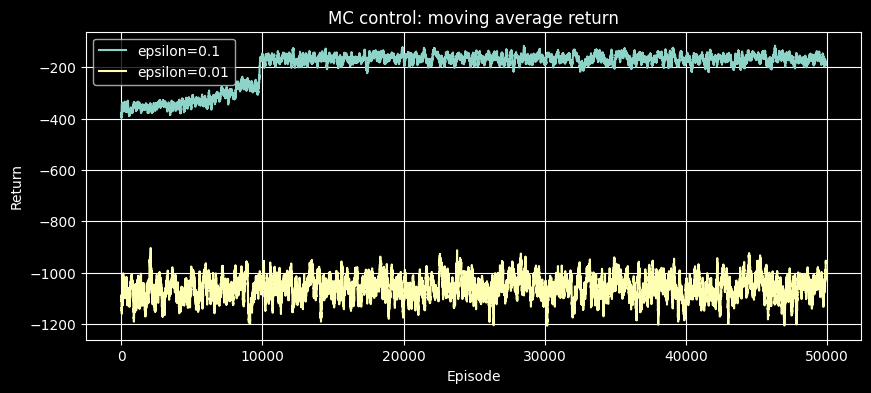

2) MC control stability over 10 independent runs (epsilon=0.1)


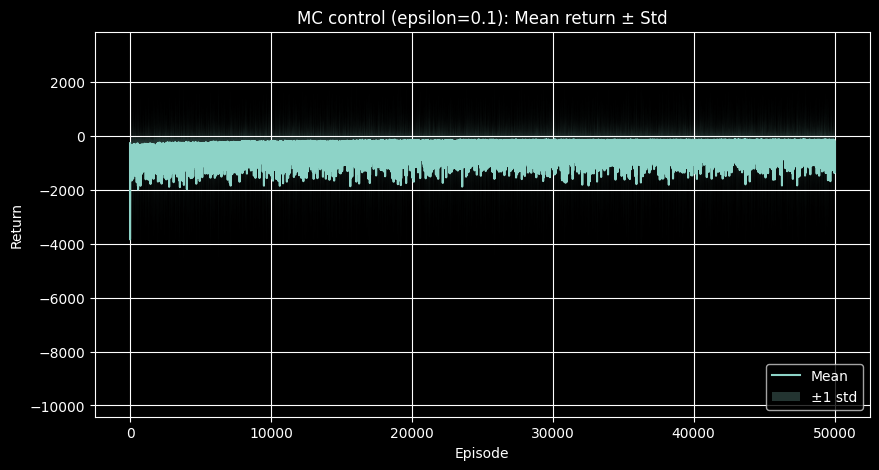

3) Importance Sampling prediction (states 36, 29, 5)
State 36: OIS last=0.000 | WIS last=0.000


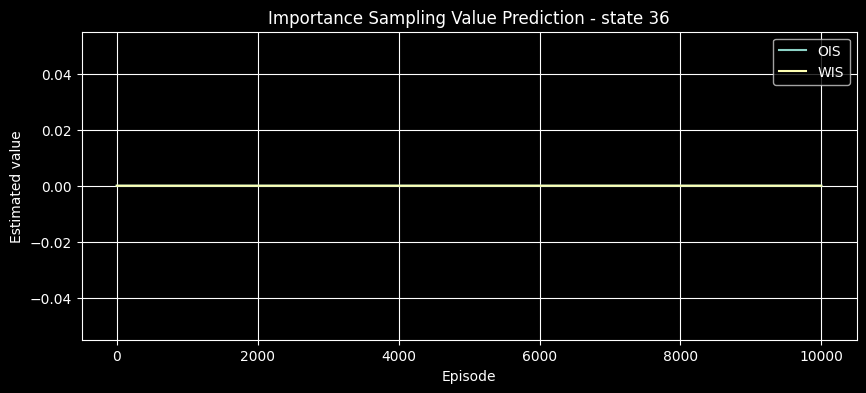

State 29: OIS last=0.000 | WIS last=0.000


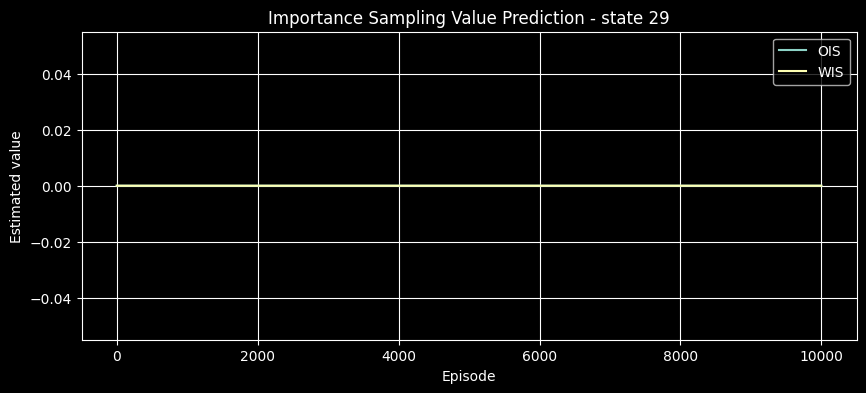

State 5: OIS last=0.000 | WIS last=0.000


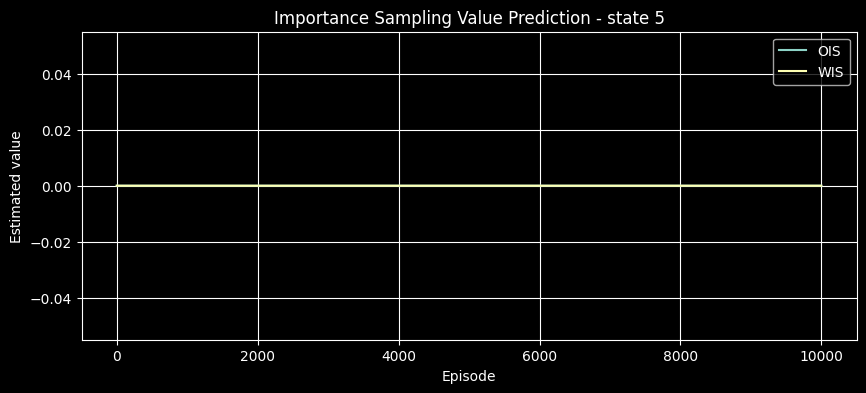

4) Prediction: Every-visit MC vs TD(0)


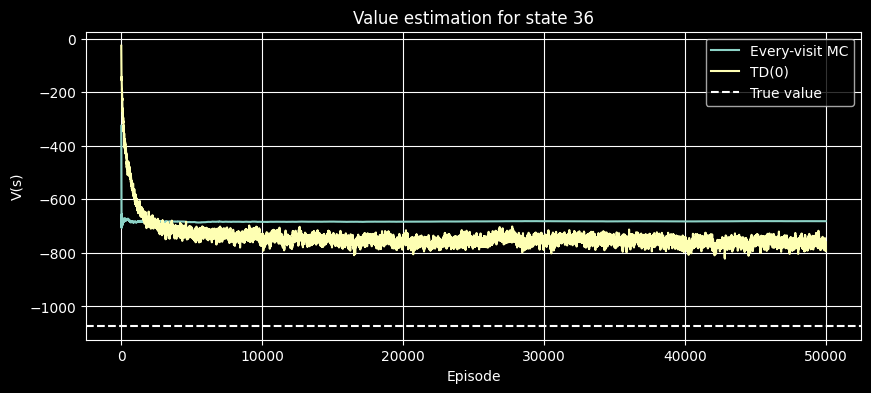

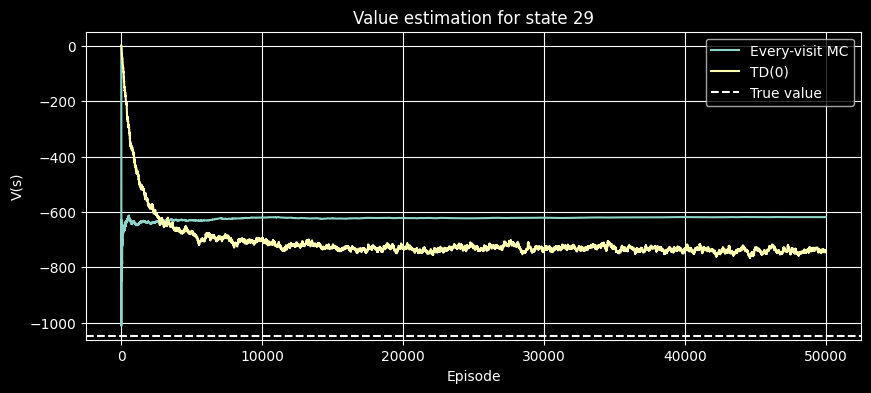

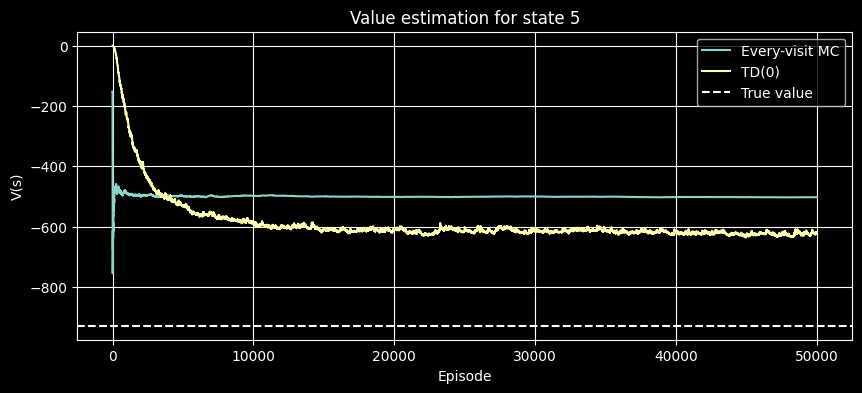

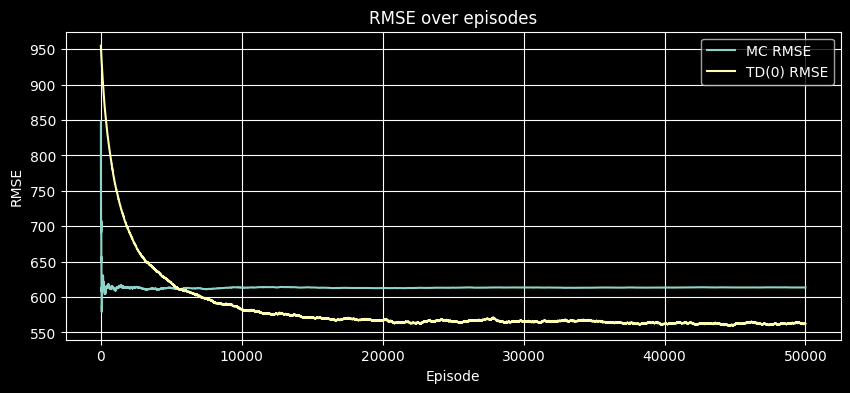

5) n-step TD


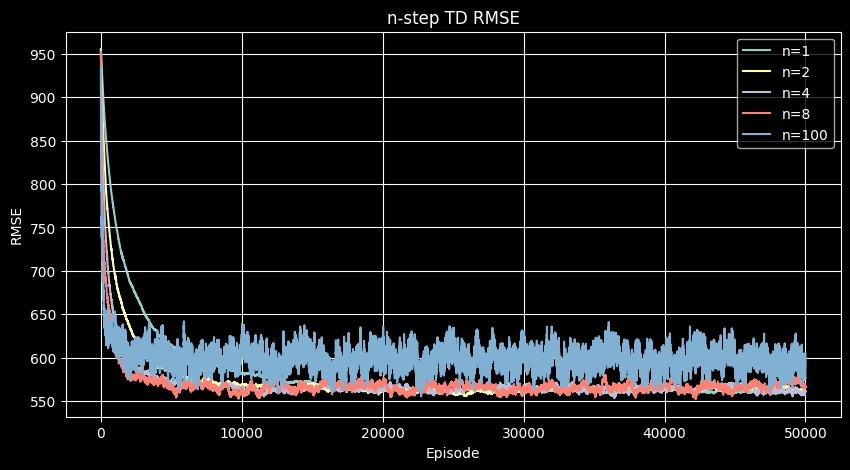

6) Control TD: SARSA / Q-learning / Expected SARSA / Double Q-learning


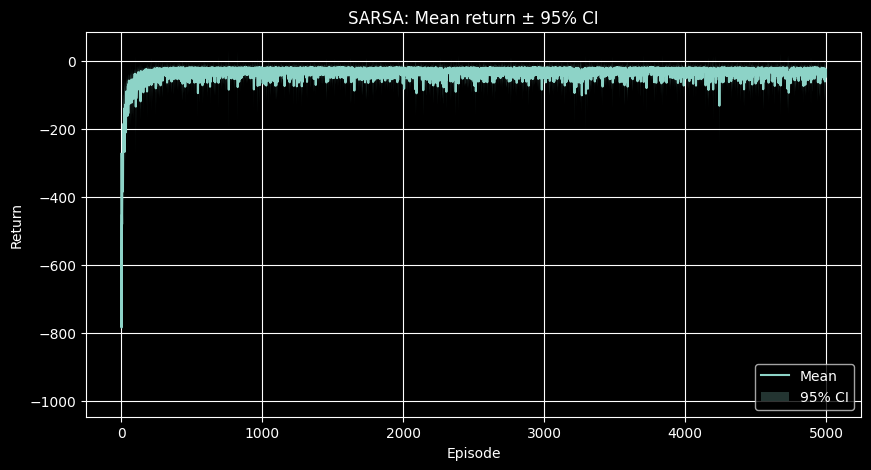

Sanity check render:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC test finished: [-249. -348. -447. -645. -447.]
Prediction test finished.


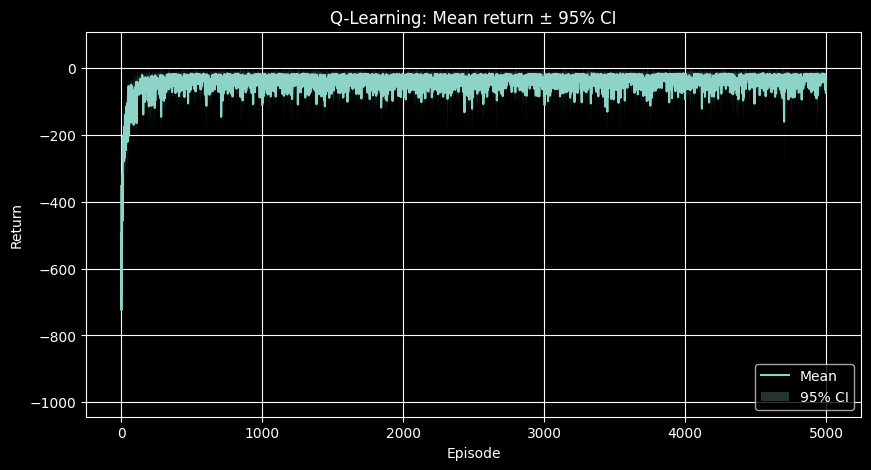

Sanity check render:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC test finished: [-249. -348. -447. -645. -447.]
Prediction test finished.


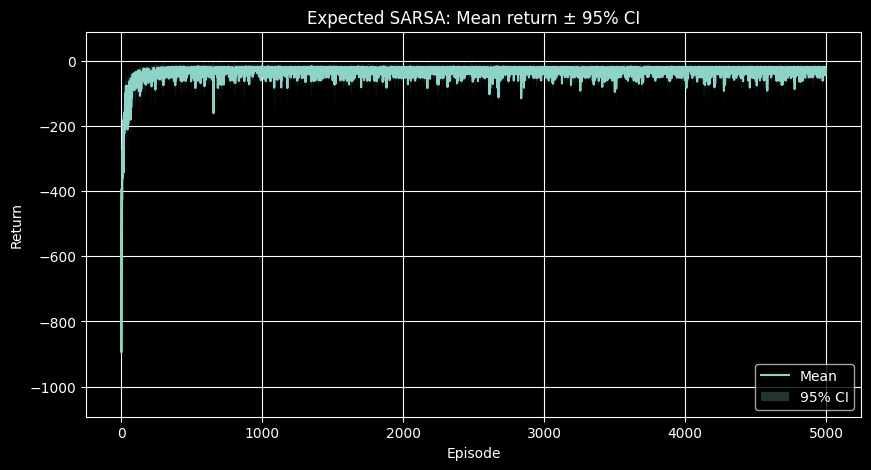

Sanity check render:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC test finished: [-249. -348. -447. -645. -447.]
Prediction test finished.


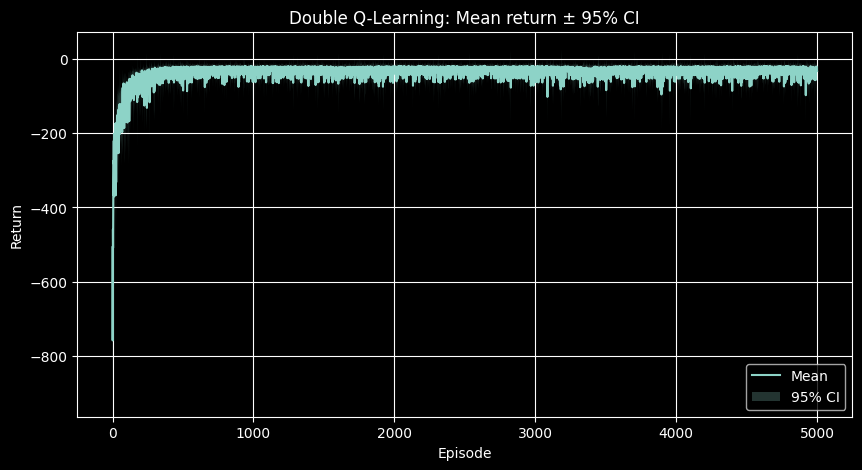

Sanity check render:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC test finished: [-249. -348. -447. -645. -447.]
Prediction test finished.
Final greedy policy - SARSA
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↑  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Final greedy policy - Q-Learning
 →  →  →  →  →  →  →  →  →  →  →  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Final greedy policy - Expected SARSA
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  →  ↑  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Final greedy policy - Double Q-Learning
 →  →  →  →  →  →  →  →  →  →  ↓  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G



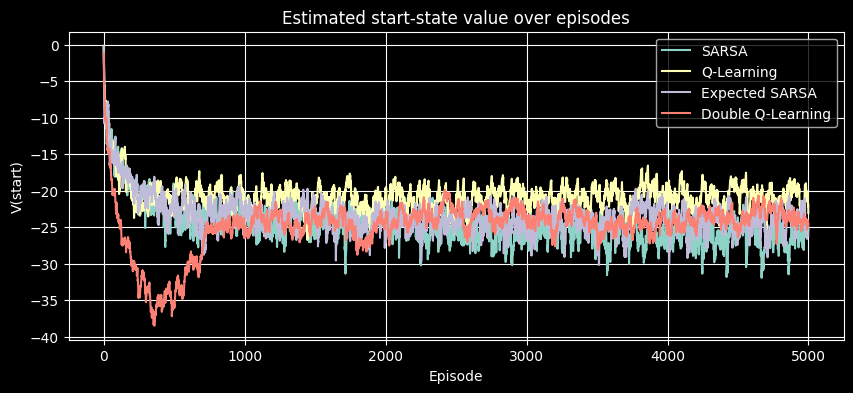

Assignment run completed.
Note: For final report, keep the plots and policy grids above.


In [28]:
"""
Optimized Colab for Stochastic Cliff Walking

Focus:
- fast environment stepping
- fast epsilon-greedy action selection
- reduced Python overhead for MC/TD/control algorithms
- safe defaults for sanity checks; increase episode counts to assignment values for final runs
"""

import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)


# -----------------------------
# Environment
# -----------------------------
class StochasticCliffWalkingEnv:
    """
    4x12 stochastic cliff walking.
    States are numbered row-major from top-left: 0..47
    Start = 36, Goal = 47, Cliff = 37..46
    Actions: 0=up, 1=right, 2=down, 3=left
    """
    def __init__(self, slip_rate=0.1, max_length=200, gamma=0.99):
        self.n_rows = 4
        self.n_cols = 12
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4
        self.slip_rate = float(slip_rate)
        self.max_length = int(max_length)
        self.gamma = float(gamma)

        self.start_state = 36
        self.goal_state = 47
        self.cliff_states = set(range(37, 47))

        self.state = self.start_state
        self.t = 0

        self.action_to_delta = {
            0: (-1, 0),  # up
            1: (0, 1),   # right
            2: (1, 0),   # down
            3: (0, -1),  # left
        }
        self.perpendicular = {
            0: [3, 1],
            1: [0, 2],
            2: [3, 1],
            3: [0, 2],
        }

        # Precompute transitions: next_state/reward/done for the 3 stochastic branches
        self.branch_action = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.next_state = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.reward = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)
        self.done = np.empty((self.n_states, self.n_actions, 3), dtype=np.bool_)
        self.branch_prob = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)

        self._precompute()

    def _to_rc(self, s):
        return divmod(int(s), self.n_cols)

    def _to_s(self, r, c):
        return r * self.n_cols + c

    def _move(self, s, a):
        r, c = self._to_rc(s)
        dr, dc = self.action_to_delta[int(a)]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.n_rows and 0 <= nc < self.n_cols):
            return int(s)
        return self._to_s(nr, nc)

    def _precompute(self):
        p_main = 1.0 - self.slip_rate
        p_slip = self.slip_rate / 2.0

        for s in range(self.n_states):
            for a in range(self.n_actions):
                branches = [a, *self.perpendicular[a]]
                probs = [p_main, p_slip, p_slip]
                for k, (ra, p) in enumerate(zip(branches, probs)):
                    self.branch_action[s, a, k] = ra
                    self.branch_prob[s, a, k] = p

                    if s == self.goal_state:
                        ns, r, d = self.goal_state, 0.0, True
                    else:
                        ns = self._move(s, ra)
                        r, d = -1.0, False
                        if ns in self.cliff_states:
                            ns, r, d = self.start_state, -100.0, False
                        elif ns == self.goal_state:
                            r, d = 0.0, True

                    self.next_state[s, a, k] = ns
                    self.reward[s, a, k] = r
                    self.done[s, a, k] = d

    def reset(self, state=None):
        self.state = self.start_state if state is None else int(state)
        self.t = 0
        return self.state

    def step(self, a):
        self.t += 1
        a = int(a)

        u = np.random.rand()
        p0 = self.branch_prob[self.state, a, 0]
        p1 = p0 + self.branch_prob[self.state, a, 1]

        if u < p0:
            k = 0
        elif u < p1:
            k = 1
        else:
            k = 2

        ns = int(self.next_state[self.state, a, k])
        r = float(self.reward[self.state, a, k])
        done = bool(self.done[self.state, a, k])
        extra = {
            "actual_action": int(self.branch_action[self.state, a, k]),
            "cliff": (r == -100.0),
            "timeout": False,
        }

        if self.t >= self.max_length and not done:
            r = -50.0
            done = True
            extra["timeout"] = True

        self.state = ns
        return ns, r, done, extra

    def render(self, agent_state=None):
        grid = []
        for r in range(self.n_rows):
            row = []
            for c in range(self.n_cols):
                s = self._to_s(r, c)
                if s == self.start_state:
                    ch = "S"
                elif s == self.goal_state:
                    ch = "G"
                elif s in self.cliff_states:
                    ch = "C"
                else:
                    ch = "."
                row.append(ch)
            grid.append(row)

        if agent_state is not None:
            rr, cc = self._to_rc(agent_state)
            grid[rr][cc] = "A"

        for row in grid:
            print(" ".join(row))
        print()


# -----------------------------
# Helpers
# -----------------------------
ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}


def eps_greedy_action(Q_s, epsilon):
    if np.random.rand() < epsilon:
        return int(np.random.randint(Q_s.shape[0]))
    return int(np.argmax(Q_s))


def eps_greedy_probs(Q_s, epsilon):
    nA = Q_s.shape[0]
    probs = np.ones(nA, dtype=np.float64) * (epsilon / nA)
    probs[int(np.argmax(Q_s))] += 1.0 - epsilon
    return probs


def print_policy_grid_from_Q(Q, env):
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                row.append("S")
            elif s == env.goal_state:
                row.append("G")
            elif s in env.cliff_states:
                row.append("C")
            else:
                row.append(ARROWS[int(np.argmax(Q[s]))])
        print(" ".join(f"{x:>2}" for x in row))
    print()


def render_path_on_grid(env, path):
    path_set = set(path)
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                ch = "S"
            elif s == env.goal_state:
                ch = "G"
            elif s in env.cliff_states:
                ch = "C"
            elif s in path_set:
                ch = "*"
            else:
                ch = "."
            row.append(ch)
        print(" ".join(row))
    print()


def moving_average(x, w=100):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")


# -----------------------------
# Episode generation
# -----------------------------
def episode_generate(pi, env, render=False, start_state=None):
    states = []
    actions = []
    rewards = []

    s = env.reset(start_state)
    states.append(s)

    if render:
        env.render(agent_state=s)

    done = False
    while not done:
        a = int(np.random.choice(env.n_actions, p=pi(s)))
        ns, r, done, extra = env.step(a)
        actions.append(a)
        rewards.append(r)
        states.append(ns)
        if render:
            print(f"s={s} a={a} r={r} ns={ns} extra={extra}")
            env.render(agent_state=ns)
        s = ns

    return rewards, actions, states


def generate_episode_eps_greedy(env, Q, epsilon=0.1, start_state=None):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    while not done:
        a = eps_greedy_action(Q[s], epsilon)
        ns, r, done, extra = env.step(a)
        states.append(ns)
        actions.append(a)
        rewards.append(r)
        s = ns

    return states, actions, rewards


def generate_episode_uniform(env, start_state):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    while not done:
        a = int(np.random.randint(env.n_actions))
        ns, r, done, extra = env.step(a)
        states.append(ns)
        actions.append(a)
        rewards.append(r)
        s = ns

    return states, actions, rewards


# -----------------------------
# Monte Carlo control
# -----------------------------
def first_visit_mc_control(env, num_episodes=50000, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns_sum = np.zeros_like(Q)
    returns_count = np.zeros_like(Q)

    episode_returns = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        rewards, actions, states = episode_generate(lambda s: eps_greedy_probs(Q[s], epsilon), env)
        G = 0.0
        visited = set()
        ep_ret = 0.0

        for t in range(len(actions) - 1, -1, -1):
            s = states[t]
            a = actions[t]
            r = rewards[t]
            ep_ret += r
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s, a] += G
                returns_count[s, a] += 1.0
                Q[s, a] = returns_sum[s, a] / returns_count[s, a]

        episode_returns[ep] = ep_ret

    return Q, episode_returns


def sample_policy_path(env, Q, max_steps=200):
    s = env.reset()
    path = [s]
    rewards = []
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        ns, r, done, extra = env.step(a)
        path.append(ns)
        rewards.append(r)
        s = ns
        if done:
            break
    return path, rewards


# -----------------------------
# Importance sampling prediction
# -----------------------------
def ordinary_and_weighted_is_prediction(env, Q_target, start_state, n_episodes=10000, gamma=0.99, seed=42):
    """
    Behavior policy: uniform random
    Target policy: deterministic greedy wrt Q_target
    """
    set_seed(seed)
    ordinary_est = 0.0
    weighted_est = 0.0
    ordinary_c = 0.0
    weighted_c = 0.0

    curve_ordinary = np.zeros(n_episodes, dtype=np.float64)
    curve_weighted = np.zeros(n_episodes, dtype=np.float64)

    for ep in range(n_episodes):
        states, actions, rewards = generate_episode_uniform(env, start_state)

        # fast deterministic target check
        greedy_actions = np.argmax(Q_target[np.array(states[:-1])], axis=1)
        if np.any(np.array(actions) != greedy_actions):
            rho = 0.0
        else:
            rho = float(env.n_actions ** len(actions))  # (1 / 0.25)^T = 4^T

        G = 0.0
        for r in reversed(rewards):
            G = gamma * G + r

        ordinary_c += 1.0
        ordinary_est += (rho * G - ordinary_est) / ordinary_c

        weighted_c += rho
        if weighted_c != 0.0:
            weighted_est += (rho / weighted_c) * (G - weighted_est)

        curve_ordinary[ep] = ordinary_est
        curve_weighted[ep] = weighted_est

    return curve_ordinary, curve_weighted


# -----------------------------
# Model-based policy evaluation
# -----------------------------
def build_transition_model(env):
    P = {s: {a: [] for a in range(env.n_actions)} for s in range(env.n_states)}
    for s in range(env.n_states):
        for a in range(env.n_actions):
            for k in range(3):
                p = float(env.branch_prob[s, a, k])
                ns = int(env.next_state[s, a, k])
                r = float(env.reward[s, a, k])
                d = bool(env.done[s, a, k])
                P[s][a].append((p, ns, r, d))
    return P


def policy_evaluation_iterative(P, policy, gamma=0.99, theta=1e-10, n_states=48, n_actions=4):
    V = np.zeros(n_states, dtype=np.float64)
    while True:
        delta = 0.0
        for s in range(n_states):
            old = V[s]
            new = 0.0
            probs = policy(s)
            for a in range(n_actions):
                pa = probs[a]
                if pa == 0.0:
                    continue
                for p, ns, r, done in P[s][a]:
                    new += pa * p * (r + (0.0 if done else gamma * V[ns]))
            V[s] = new
            delta = max(delta, abs(old - new))
        if delta < theta:
            break
    return V


# -----------------------------
# Prediction: Every-visit MC and TD(0)
# -----------------------------
def every_visit_mc_prediction(env, policy, V_true, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    counts = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode_uniform(env, env.start_state)
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = gamma * G + r
            returns.append(G)
        returns = returns[::-1]

        for t, s in enumerate(states[:-1]):
            counts[s] += 1.0
            V[s] += (returns[t] - V[s]) / counts[s]

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


def td0_prediction(env, policy, V_true, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        while not done:
            a = int(np.random.choice(env.n_actions, p=policy(s)))
            ns, r, done, extra = env.step(a)
            target = r + (0.0 if done else gamma * V[ns])
            V[s] += alpha * (target - V[s])
            s = ns

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


def n_step_td_prediction(env, policy, V_true, n=1, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states = [env.reset()]
        rewards = [0.0]
        T = math.inf
        t = 0

        while True:
            if t < T:
                s_t = states[t]
                a_t = int(np.random.choice(env.n_actions, p=policy(s_t)))
                ns, r, done, extra = env.step(a_t)
                states.append(ns)
                rewards.append(r)
                if done:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = min(tau + n, T)
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                if tau + n < T:
                    G += (gamma ** n) * V[states[tau + n]]
                s_tau = states[tau]
                if s_tau != env.goal_state:
                    V[s_tau] += alpha * (G - V[s_tau])

            if tau == T - 1:
                break
            t += 1

        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse


# -----------------------------
# Control: SARSA, Q-learning, Expected SARSA, Double Q-learning
# -----------------------------
def sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        a = eps_greedy_action(Q[s], epsilon)
        done = False
        ep_return = 0.0

        while not done:
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                target = r
                Q[s, a] += alpha * (target - Q[s, a])
                break
            na = eps_greedy_action(Q[ns], epsilon)
            target = r + gamma * Q[ns, na]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = ns, na

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            target = r if done else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def expected_sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                target = r
            else:
                probs = eps_greedy_probs(Q[ns], epsilon)
                target = r + gamma * np.sum(probs * Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def double_q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q1 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    Q2 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            Qsum = Q1 + Q2
            a = eps_greedy_action(Qsum[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if np.random.rand() < 0.5:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q1[ns]))
                    target = r + gamma * Q2[ns, a_star]
                Q1[s, a] += alpha * (target - Q1[s, a])
            else:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q2[ns]))
                    target = r + gamma * Q1[ns, a_star]
                Q2[s, a] += alpha * (target - Q2[s, a])

            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max((Q1[env.start_state] + Q2[env.start_state]) / 2.0)

    return (Q1, Q2), returns, start_values


# -----------------------------
# Experiment utilities
# -----------------------------
def run_multiple_mc(env_factory, n_runs=10, num_episodes=50000, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_Q = []

    for run in range(n_runs):
        env = env_factory()
        Q, ep_returns = first_visit_mc_control(env, num_episodes=num_episodes, epsilon=epsilon, gamma=gamma, seed=run + 123)
        all_returns[run] = ep_returns
        all_Q.append(Q)

    return all_Q, all_returns


def run_control_algo(algo_fn, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_start_values = np.zeros((n_runs, num_episodes), dtype=np.float64)
    final_Qs = []

    for run in range(n_runs):
        env = env_factory()
        out = algo_fn(env, num_episodes=num_episodes, alpha=alpha, epsilon=epsilon, gamma=gamma, seed=run + 10)
        if algo_fn.__name__ == "double_q_learning":
            (Q1, Q2), returns, start_vals = out
            final_Q = (Q1 + Q2) / 2.0
        else:
            Q, returns, start_vals = out
            final_Q = Q

        all_returns[run] = returns
        all_start_values[run] = start_vals
        final_Qs.append(final_Q)

    return all_returns, all_start_values, final_Qs


def plot_mean_std_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.25, label="±1 std")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_mean_ci_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])

    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - ci, mean + ci, alpha=0.25, label="95% CI")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


# -----------------------------
# Example main
# -----------------------------

    env = StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)
    print("Sanity check render:")
    env.render()

    # For quick test only
    Q_test, ret_test = first_visit_mc_control(env, num_episodes=50, epsilon=0.1, gamma=0.99, seed=1)
    print("MC test finished:", ret_test[:5])

    P = build_transition_model(env)
    random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
    V_true = policy_evaluation_iterative(P, random_policy, gamma=0.99)

    V_mc, rmse_mc, traj_mc = every_visit_mc_prediction(env, random_policy, V_true, num_episodes=100, gamma=0.99, seed=1)
    V_td, rmse_td, traj_td = td0_prediction(env, random_policy, V_true, alpha=0.01, num_episodes=100, gamma=0.99, seed=1)
    print("Prediction test finished.")

# -----------------------------
# Full assignment runner
# -----------------------------
def run_assignment_full():
    """
    Runs the full homework suite and prints/plots the outputs requested in the assignment.
    Recommended to run in Colab with one section at a time if runtime is tight.
    """
    set_seed(42)
    env_factory = lambda: StochasticCliffWalkingEnv(slip_rate=0.1, max_length=200, gamma=0.99)
    env = env_factory()

    print("=" * 80)
    print("1) Monte Carlo control: epsilon = 0.1 and 0.01")
    print("=" * 80)
    Q_mc_01, ret_mc_01 = first_visit_mc_control(env_factory(), num_episodes=50000, epsilon=0.1, gamma=0.99, seed=1)
    Q_mc_001, ret_mc_001 = first_visit_mc_control(env_factory(), num_episodes=50000, epsilon=0.01, gamma=0.99, seed=2)

    print("Final greedy policy for epsilon=0.1")
    print_policy_grid_from_Q(Q_mc_01, env)
    path_01, _ = sample_policy_path(env_factory(), Q_mc_01)
    print("Sample greedy path for epsilon=0.1")
    render_path_on_grid(env, path_01)

    print("Final greedy policy for epsilon=0.01")
    print_policy_grid_from_Q(Q_mc_001, env)
    path_001, _ = sample_policy_path(env_factory(), Q_mc_001)
    print("Sample greedy path for epsilon=0.01")
    render_path_on_grid(env, path_001)

    plt.figure(figsize=(10, 4))
    plt.plot(moving_average(ret_mc_01, 100), label="epsilon=0.1")
    plt.plot(moving_average(ret_mc_001, 100), label="epsilon=0.01")
    plt.title("MC control: moving average return")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("=" * 80)
    print("2) MC control stability over 10 independent runs (epsilon=0.1)")
    print("=" * 80)
    mc_all_returns = []
    mc_all_Q = []
    for run in range(10):
        Q_tmp, ret_tmp = first_visit_mc_control(env_factory(), num_episodes=50000, epsilon=0.1, gamma=0.99, seed=100 + run)
        mc_all_returns.append(ret_tmp)
        mc_all_Q.append(Q_tmp)

    mc_all_returns = np.asarray(mc_all_returns)
    plot_mean_std_curve(mc_all_returns, title="MC control (epsilon=0.1): Mean return ± Std", xlabel="Episode", ylabel="Return")

    print("=" * 80)
    print("3) Importance Sampling prediction (states 36, 29, 5)")
    print("=" * 80)
    Q_target = Q_mc_01
    for s in [36, 29, 5]:
        o_curve, w_curve = ordinary_and_weighted_is_prediction(
            env_factory(), Q_target, start_state=s, n_episodes=10000, gamma=0.99, seed=200 + s
        )
        print(f"State {s}: OIS last={o_curve[-1]:.3f} | WIS last={w_curve[-1]:.3f}")
        plt.figure(figsize=(10, 4))
        plt.plot(o_curve, label="OIS")
        plt.plot(w_curve, label="WIS")
        plt.title(f"Importance Sampling Value Prediction - state {s}")
        plt.xlabel("Episode")
        plt.ylabel("Estimated value")
        plt.legend()
        plt.grid(True)
        plt.show()

    print("=" * 80)
    print("4) Prediction: Every-visit MC vs TD(0)")
    print("=" * 80)
    P = build_transition_model(env)
    random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
    V_true = policy_evaluation_iterative(P, random_policy, gamma=0.99, n_states=env.n_states, n_actions=env.n_actions)

    V_mc, rmse_mc, traj_mc = every_visit_mc_prediction(env_factory(), random_policy, V_true, num_episodes=50000, gamma=0.99, seed=300)
    V_td, rmse_td, traj_td = td0_prediction(env_factory(), random_policy, V_true, alpha=0.01, num_episodes=50000, gamma=0.99, seed=300)

    for s in [36, 29, 5]:
        plt.figure(figsize=(10, 4))
        plt.plot(traj_mc[s], label="Every-visit MC")
        plt.plot(traj_td[s], label="TD(0)")
        plt.axhline(V_true[s], linestyle="--", label="True value")
        plt.title(f"Value estimation for state {s}")
        plt.xlabel("Episode")
        plt.ylabel("V(s)")
        plt.legend()
        plt.grid(True)
        plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(rmse_mc, label="MC RMSE")
    plt.plot(rmse_td, label="TD(0) RMSE")
    plt.title("RMSE over episodes")
    plt.xlabel("Episode")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("=" * 80)
    print("5) n-step TD")
    print("=" * 80)
    n_values = [1, 2, 4, 8, 100]
    nstep_curves = {}
    for n in n_values:
        _, rmse_n = n_step_td_prediction(env_factory(), random_policy, V_true, n=n, alpha=0.01, num_episodes=50000, gamma=0.99, seed=400 + n)
        nstep_curves[n] = rmse_n

    plt.figure(figsize=(10, 5))
    for n in n_values:
        plt.plot(nstep_curves[n], label=f"n={n}")
    plt.title("n-step TD RMSE")
    plt.xlabel("Episode")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("=" * 80)
    print("6) Control TD: SARSA / Q-learning / Expected SARSA / Double Q-learning")
    print("=" * 80)
    sarsa_returns_runs, sarsa_start_runs, sarsa_Qs = run_control_algo(
        sarsa, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99
    )
    q_returns_runs, q_start_runs, q_Qs = run_control_algo(
        q_learning, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99
    )
    exp_returns_runs, exp_start_runs, exp_Qs = run_control_algo(
        expected_sarsa, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99
    )
    d_returns_runs, d_start_runs, d_Qs = run_control_algo(
        double_q_learning, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99
    )

    plot_mean_ci_curve(sarsa_returns_runs, title="SARSA: Mean return ± 95% CI", xlabel="Episode", ylabel="Return")
    plot_mean_ci_curve(q_returns_runs, title="Q-Learning: Mean return ± 95% CI", xlabel="Episode", ylabel="Return")
    plot_mean_ci_curve(exp_returns_runs, title="Expected SARSA: Mean return ± 95% CI", xlabel="Episode", ylabel="Return")
    plot_mean_ci_curve(d_returns_runs, title="Double Q-Learning: Mean return ± 95% CI", xlabel="Episode", ylabel="Return")

    print("Final greedy policy - SARSA")
    print_policy_grid_from_Q(sarsa_Qs[-1], env)
    print("Final greedy policy - Q-Learning")
    print_policy_grid_from_Q(q_Qs[-1], env)
    print("Final greedy policy - Expected SARSA")
    print_policy_grid_from_Q(exp_Qs[-1], env)
    print("Final greedy policy - Double Q-Learning")
    print_policy_grid_from_Q(d_Qs[-1], env)

    plt.figure(figsize=(10, 4))
    plt.plot(sarsa_start_runs.mean(axis=0), label="SARSA")
    plt.plot(q_start_runs.mean(axis=0), label="Q-Learning")
    plt.plot(exp_start_runs.mean(axis=0), label="Expected SARSA")
    plt.plot(d_start_runs.mean(axis=0), label="Double Q-Learning")
    plt.title("Estimated start-state value over episodes")
    plt.xlabel("Episode")
    plt.ylabel("V(start)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("=" * 80)
    print("Assignment run completed.")
    print("Note: For final report, keep the plots and policy grids above.")
    print("=" * 80)


if __name__ == "__main__":
    # By default, run the full assignment suite.
    # If you only want a smoke test, call smoke_test() manually in Colab.
    run_assignment_full()


# Temp2(Local)

Environment check:
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G

MC smoke test OK: [-249. -348. -447. -645. -447.]
Prediction smoke test OK: [751.76858294 748.4244652  738.97818715] [955.13760732 954.72760534 954.17018025]


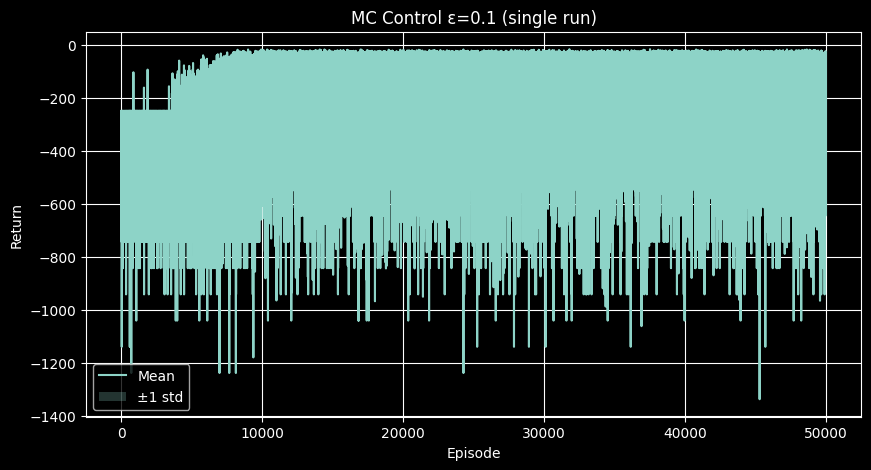

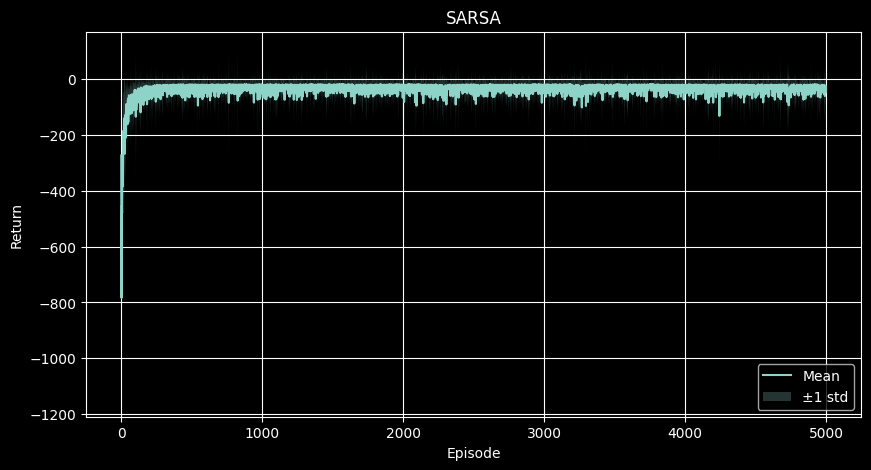

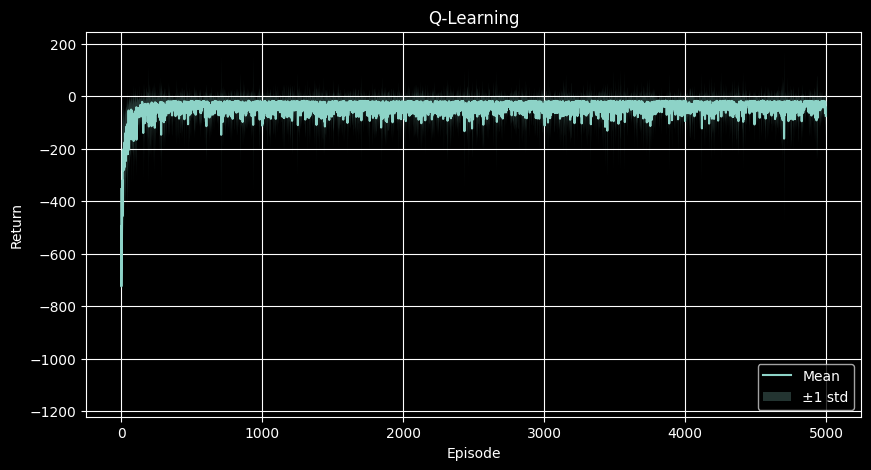

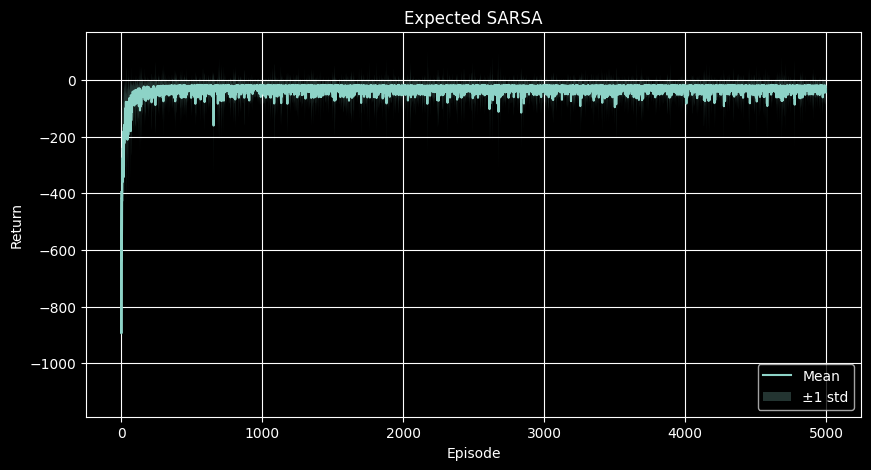

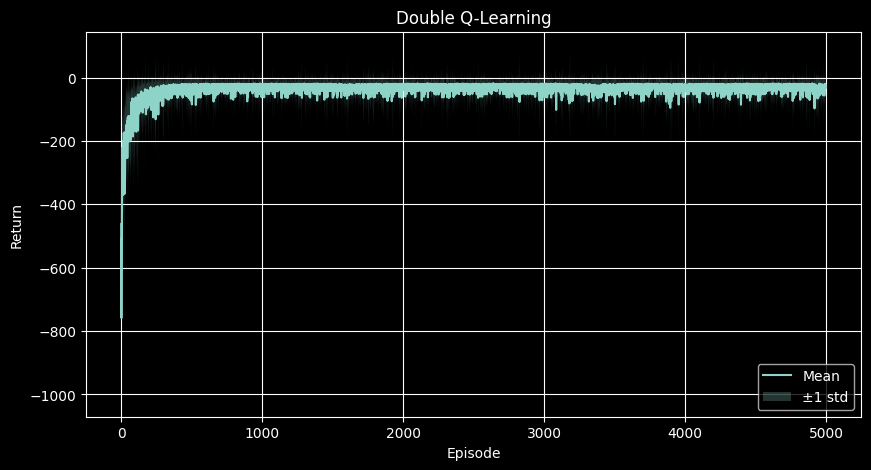

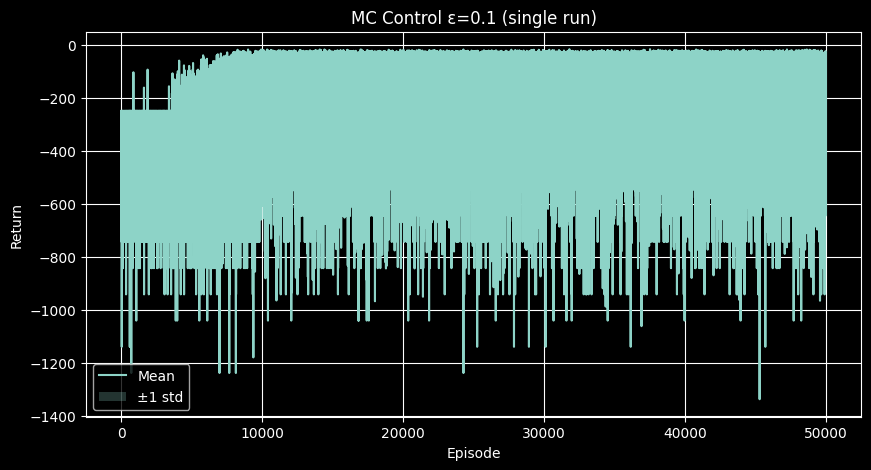

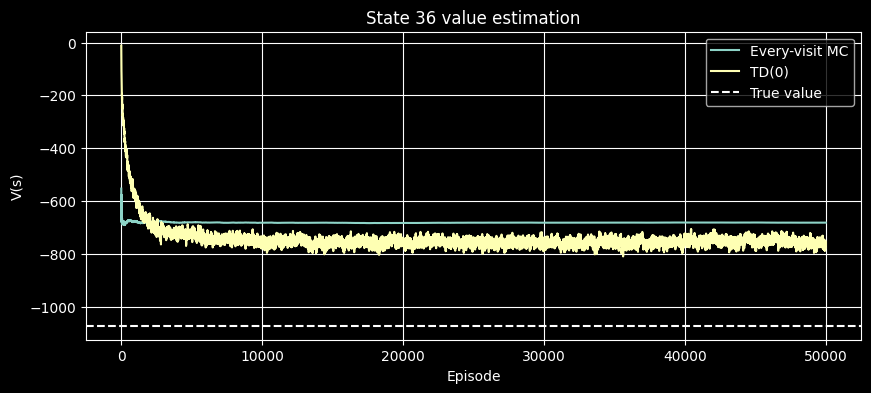

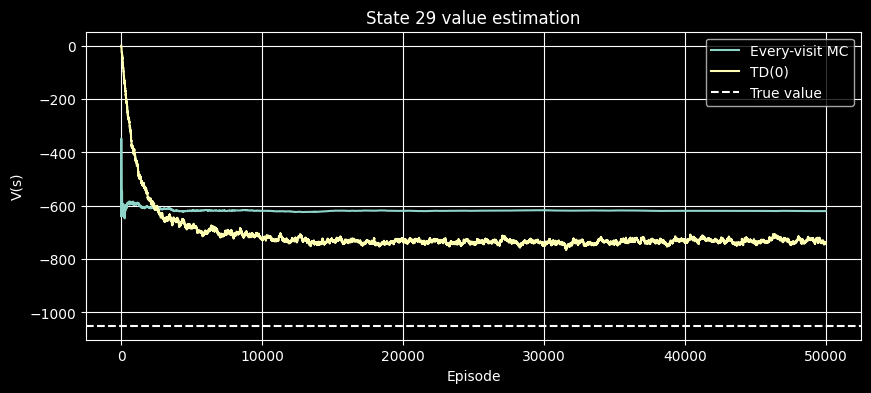

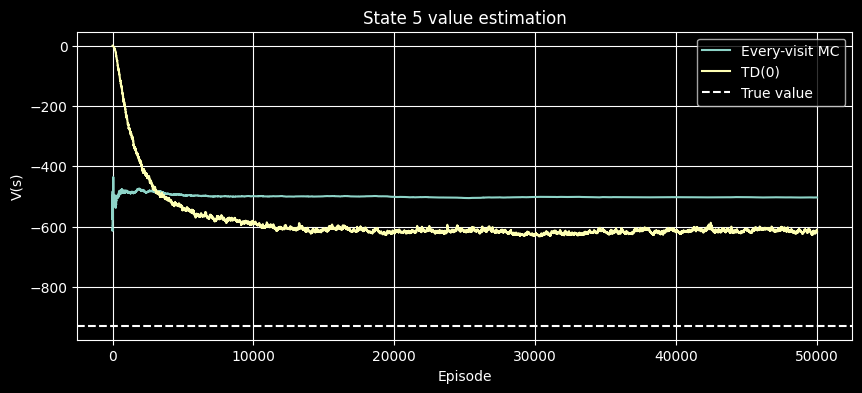

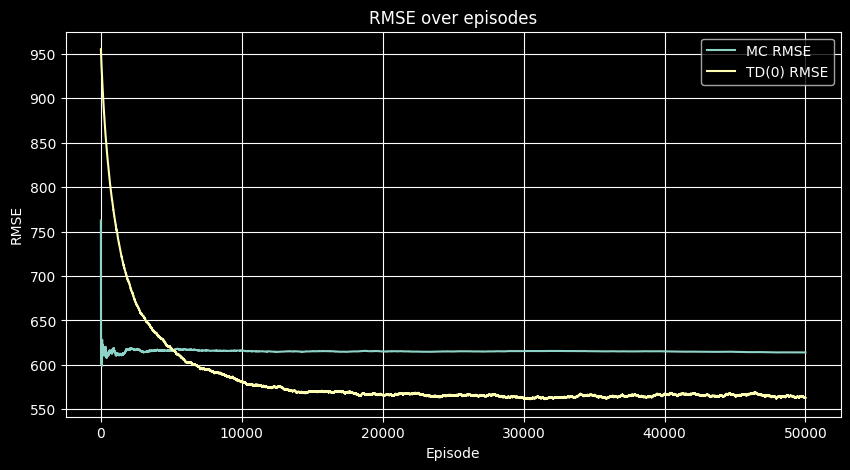

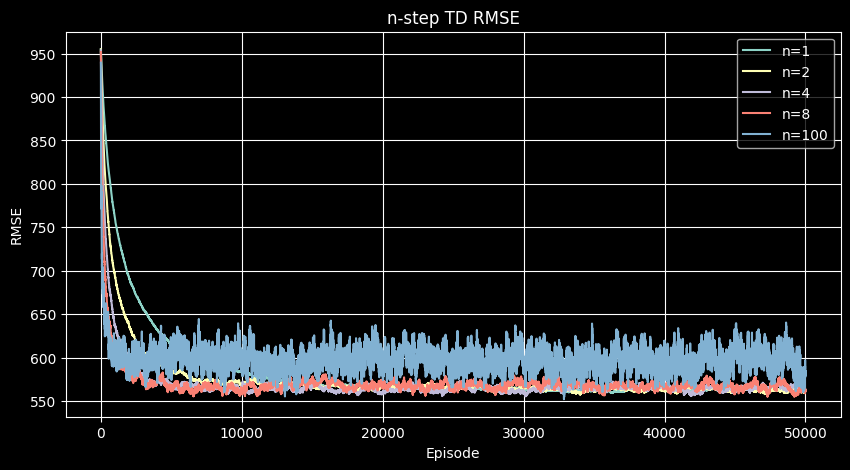

Final policies:
SARSA
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↑  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Q-Learning
 →  →  →  →  →  →  →  →  →  →  →  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Expected SARSA
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  →  ↑  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  →  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

Double Q-Learning
 →  →  →  →  →  →  →  →  →  →  ↓  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  →  →  ↓
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↓
 S  C  C  C  C  C  C  C  C  C  C  G



In [1]:
"""
RL HW2 — Local-safe / Colab-safe implementation for Stochastic Cliff Walking

Design goals:
- Fast enough to run in Colab or on a local CPU
- Safe for your machine: no automatic heavy runs on import

Recommended workflow:
1) Run the smoke tests first
2) Then enable only one experiment block at a time
3) Keep rendering OFF during training
"""

import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Config
# ============================================================
@dataclass
class Config:
    gamma: float = 0.99
    slip_rate: float = 0.1
    max_length: int = 200

    # Assignment values
    mc_control_episodes: int = 50000
    is_episodes: int = 10000
    pred_episodes: int = 50000
    control_episodes: int = 5000
    control_runs: int = 10

    # Training hyperparameters
    epsilon_mc_1: float = 0.1
    epsilon_mc_2: float = 0.01
    epsilon_control: float = 0.1
    alpha_td: float = 0.01
    alpha_control: float = 0.1
    alpha_expected_sarsa_big: float = 0.5

    # n-step values
    n_values = (1, 2, 4, 8, 100)

    # Safety / usability
    render_during_training: bool = False
    smoke_test_episodes: int = 200
    smoke_test_runs: int = 2

    # If True, heavy experiments will run in __main__
    run_full_suite: bool = False


CFG = Config()


# ============================================================
# Reproducibility
# ============================================================
def set_seed(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)


# ============================================================
# Environment
# ============================================================
class StochasticCliffWalkingEnv:
    """
    4x12 stochastic cliff walking.
    States are numbered row-major from top-left: 0..47
    Start = 36, Goal = 47, Cliff = 37..46
    Actions: 0=up, 1=right, 2=down, 3=left
    """

    def __init__(self, slip_rate=0.1, max_length=200, gamma=0.99):
        self.n_rows = 4
        self.n_cols = 12
        self.n_states = self.n_rows * self.n_cols
        self.n_actions = 4

        self.slip_rate = float(slip_rate)
        self.max_length = int(max_length)
        self.gamma = float(gamma)

        self.start_state = 36
        self.goal_state = 47
        self.cliff_states = set(range(37, 47))

        self.state = self.start_state
        self.t = 0

        self.action_to_delta = {
            0: (-1, 0),  # up
            1: (0, 1),   # right
            2: (1, 0),   # down
            3: (0, -1),  # left
        }
        self.perpendicular = {
            0: [3, 1],
            1: [0, 2],
            2: [3, 1],
            3: [0, 2],
        }

        self.branch_action = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.next_state = np.empty((self.n_states, self.n_actions, 3), dtype=np.int16)
        self.reward = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)
        self.done = np.empty((self.n_states, self.n_actions, 3), dtype=np.bool_)
        self.branch_prob = np.empty((self.n_states, self.n_actions, 3), dtype=np.float32)
        self._precompute()

    def _to_rc(self, s):
        return divmod(int(s), self.n_cols)

    def _to_s(self, r, c):
        return r * self.n_cols + c

    def _move(self, s, a):
        r, c = self._to_rc(s)
        dr, dc = self.action_to_delta[int(a)]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.n_rows and 0 <= nc < self.n_cols):
            return int(s)
        return self._to_s(nr, nc)

    def _precompute(self):
        p_main = 1.0 - self.slip_rate
        p_slip = self.slip_rate / 2.0

        for s in range(self.n_states):
            for a in range(self.n_actions):
                branches = [a, *self.perpendicular[a]]
                probs = [p_main, p_slip, p_slip]
                for k, (ra, p) in enumerate(zip(branches, probs)):
                    self.branch_action[s, a, k] = ra
                    self.branch_prob[s, a, k] = p

                    if s == self.goal_state:
                        ns, r, d = self.goal_state, 0.0, True
                    else:
                        ns = self._move(s, ra)
                        r, d = -1.0, False
                        if ns in self.cliff_states:
                            ns, r, d = self.start_state, -100.0, False
                        elif ns == self.goal_state:
                            r, d = 0.0, True

                    self.next_state[s, a, k] = ns
                    self.reward[s, a, k] = r
                    self.done[s, a, k] = d

    def reset(self, state=None):
        self.state = self.start_state if state is None else int(state)
        self.t = 0
        return self.state

    def step(self, a):
        self.t += 1
        a = int(a)

        u = np.random.rand()
        p0 = self.branch_prob[self.state, a, 0]
        p1 = p0 + self.branch_prob[self.state, a, 1]

        if u < p0:
            k = 0
        elif u < p1:
            k = 1
        else:
            k = 2

        ns = int(self.next_state[self.state, a, k])
        r = float(self.reward[self.state, a, k])
        done = bool(self.done[self.state, a, k])
        extra = {
            "actual_action": int(self.branch_action[self.state, a, k]),
            "cliff": (r == -100.0),
            "timeout": False,
        }

        if self.t >= self.max_length and not done:
            r = -50.0
            done = True
            extra["timeout"] = True

        self.state = ns
        return ns, r, done, extra

    def render(self, agent_state=None):
        grid = []
        for r in range(self.n_rows):
            row = []
            for c in range(self.n_cols):
                s = self._to_s(r, c)
                if s == self.start_state:
                    ch = "S"
                elif s == self.goal_state:
                    ch = "G"
                elif s in self.cliff_states:
                    ch = "C"
                else:
                    ch = "."
                row.append(ch)
            grid.append(row)

        if agent_state is not None:
            rr, cc = self._to_rc(agent_state)
            grid[rr][cc] = "A"

        for row in grid:
            print(" ".join(row))
        print()

    def transition_model(self):
        """
        Build P[s][a] = list of (prob, next_state, reward, done)
        for exact dynamic-programming evaluation.
        """
        P = {s: {a: [] for a in range(self.n_actions)} for s in range(self.n_states)}
        for s in range(self.n_states):
            for a in range(self.n_actions):
                for k in range(3):
                    P[s][a].append(
                        (
                            float(self.branch_prob[s, a, k]),
                            int(self.next_state[s, a, k]),
                            float(self.reward[s, a, k]),
                            bool(self.done[s, a, k]),
                        )
                    )
        return P


# ============================================================
# Helpers
# ============================================================
ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}


def eps_greedy_probs(Q_s, epsilon):
    nA = Q_s.shape[0]
    probs = np.ones(nA, dtype=np.float64) * (epsilon / nA)
    probs[int(np.argmax(Q_s))] += 1.0 - epsilon
    return probs


def eps_greedy_action(Q_s, epsilon):
    if np.random.rand() < epsilon:
        return int(np.random.randint(Q_s.shape[0]))
    return int(np.argmax(Q_s))


def print_policy_grid_from_Q(Q, env):
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                row.append("S")
            elif s == env.goal_state:
                row.append("G")
            elif s in env.cliff_states:
                row.append("C")
            else:
                row.append(ARROWS[int(np.argmax(Q[s]))])
        print(" ".join(f"{x:>2}" for x in row))
    print()


def render_path_on_grid(env, path):
    path_set = set(path)
    for r in range(env.n_rows):
        row = []
        for c in range(env.n_cols):
            s = r * env.n_cols + c
            if s == env.start_state:
                ch = "S"
            elif s == env.goal_state:
                ch = "G"
            elif s in env.cliff_states:
                ch = "C"
            elif s in path_set:
                ch = "*"
            else:
                ch = "."
            row.append(ch)
        print(" ".join(row))
    print()


def moving_average(x, w=100):
    x = np.asarray(x, dtype=np.float64)
    if len(x) < w:
        return x
    kernel = np.ones(w, dtype=np.float64) / w
    return np.convolve(x, kernel, mode="valid")


# ============================================================
# Episode generation
# ============================================================
def episode_generate(pi, env, render=False, start_state=None):
    states = []
    actions = []
    rewards = []

    s = env.reset(start_state)
    states.append(s)

    if render:
        env.render(agent_state=s)

    done = False
    while not done:
        a = int(np.random.choice(env.n_actions, p=pi(s)))
        ns, r, done, extra = env.step(a)

        actions.append(a)
        rewards.append(r)
        states.append(ns)

        if render:
            print(f"s={s} a={a} r={r} ns={ns} extra={extra}")
            env.render(agent_state=ns)

        s = ns

    return rewards, actions, states


def generate_episode_uniform(env, start_state):
    s = env.reset(start_state)
    states = [s]
    actions = []
    rewards = []
    done = False

    while not done:
        a = int(np.random.randint(env.n_actions))
        ns, r, done, extra = env.step(a)
        states.append(ns)
        actions.append(a)
        rewards.append(r)
        s = ns

    return states, actions, rewards


# ============================================================
# Monte Carlo Control: First-Visit
# ============================================================
def first_visit_mc_control(env, num_episodes=50000, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns_sum = np.zeros_like(Q)
    returns_count = np.zeros_like(Q)
    episode_returns = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        rewards, actions, states = episode_generate(
            lambda s: eps_greedy_probs(Q[s], epsilon),
            env,
            render=False,
        )

        G = 0.0
        visited = set()
        ep_ret = 0.0

        for t in range(len(actions) - 1, -1, -1):
            s = states[t]
            a = actions[t]
            r = rewards[t]
            ep_ret += r
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s, a] += G
                returns_count[s, a] += 1.0
                Q[s, a] = returns_sum[s, a] / returns_count[s, a]

        episode_returns[ep] = ep_ret

    return Q, episode_returns


# ============================================================
# Importance Sampling Prediction
# ============================================================
def ordinary_and_weighted_is_prediction(env, Q_target, start_state, n_episodes=10000, gamma=0.99, seed=42):
    """
    Behavior policy: uniform random
    Target policy: greedy wrt Q_target
    """
    set_seed(seed)
    ordinary_est = 0.0
    weighted_est = 0.0
    ordinary_c = 0.0
    weighted_c = 0.0

    curve_ordinary = np.zeros(n_episodes, dtype=np.float64)
    curve_weighted = np.zeros(n_episodes, dtype=np.float64)

    for ep in range(n_episodes):
        states, actions, rewards = generate_episode_uniform(env, start_state)

        # Fast importance ratio:
        # target policy is deterministic greedy, behavior is uniform random (1/4)
        greedy_actions = np.argmax(Q_target[np.array(states[:-1])], axis=1)
        if np.any(np.array(actions) != greedy_actions):
            rho = 0.0
        else:
            rho = float(env.n_actions ** len(actions))  # (1/0.25)^T

        G = 0.0
        for r in reversed(rewards):
            G = gamma * G + r

        ordinary_c += 1.0
        ordinary_est += (rho * G - ordinary_est) / ordinary_c

        weighted_c += rho
        if weighted_c != 0.0:
            weighted_est += (rho / weighted_c) * (G - weighted_est)

        curve_ordinary[ep] = ordinary_est
        curve_weighted[ep] = weighted_est

    return curve_ordinary, curve_weighted


# ============================================================
# Dynamic Programming: true V under random policy
# ============================================================
def policy_evaluation_iterative(P, policy, gamma=0.99, theta=1e-10, n_states=48, n_actions=4):
    V = np.zeros(n_states, dtype=np.float64)
    while True:
        delta = 0.0
        for s in range(n_states):
            old = V[s]
            new = 0.0
            probs = policy(s)
            for a in range(n_actions):
                pa = probs[a]
                if pa == 0.0:
                    continue
                for p, ns, r, done in P[s][a]:
                    new += pa * p * (r + (0.0 if done else gamma * V[ns]))
            V[s] = new
            delta = max(delta, abs(old - new))
        if delta < theta:
            break
    return V


# ============================================================
# Prediction: Every-Visit MC
# ============================================================
def every_visit_mc_prediction(env, policy, V_true, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    counts = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states, actions, rewards = generate_episode_uniform(env, env.start_state)

        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = gamma * G + r
            returns.append(G)
        returns = returns[::-1]

        for t, s in enumerate(states[:-1]):
            counts[s] += 1.0
            V[s] += (returns[t] - V[s]) / counts[s]

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


# ============================================================
# Prediction: TD(0)
# ============================================================
def td0_prediction(env, policy, V_true, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)

    traj = {36: np.zeros(num_episodes), 29: np.zeros(num_episodes), 5: np.zeros(num_episodes)}
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False

        while not done:
            a = int(np.random.choice(env.n_actions, p=policy(s)))
            ns, r, done, extra = env.step(a)
            target = r + (0.0 if done else gamma * V[ns])
            V[s] += alpha * (target - V[s])
            s = ns

        for key in traj:
            traj[key][ep] = V[key]
        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse, traj


# ============================================================
# Prediction: n-step TD
# ============================================================
def n_step_td_prediction(env, policy, V_true, n=1, alpha=0.01, num_episodes=50000, gamma=0.99, seed=42):
    set_seed(seed)
    V = np.zeros(env.n_states, dtype=np.float64)
    rmse = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        states = [env.reset()]
        rewards = [0.0]
        T = math.inf
        t = 0

        while True:
            if t < T:
                s_t = states[t]
                a_t = int(np.random.choice(env.n_actions, p=policy(s_t)))
                ns, r, done, extra = env.step(a_t)
                states.append(ns)
                rewards.append(r)
                if done:
                    T = t + 1

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = min(tau + n, T)
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                if tau + n < T:
                    G += (gamma ** n) * V[states[tau + n]]

                s_tau = states[tau]
                if s_tau != env.goal_state:
                    V[s_tau] += alpha * (G - V[s_tau])

            if tau == T - 1:
                break
            t += 1

        rmse[ep] = np.sqrt(np.mean((V - V_true) ** 2))

    return V, rmse


# ============================================================
# Control: SARSA / Q-learning / Expected SARSA / Double Q-learning
# ============================================================
def sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        a = eps_greedy_action(Q[s], epsilon)
        done = False
        ep_return = 0.0

        while not done:
            ns, r, done, extra = env.step(a)
            ep_return += r
            if done:
                Q[s, a] += alpha * (r - Q[s, a])
                break
            na = eps_greedy_action(Q[ns], epsilon)
            target = r + gamma * Q[ns, na]
            Q[s, a] += alpha * (target - Q[s, a])
            s, a = ns, na

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r
            target = r if done else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def expected_sarsa(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            a = eps_greedy_action(Q[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if done:
                target = r
            else:
                probs = eps_greedy_probs(Q[ns], epsilon)
                target = r + gamma * np.sum(probs * Q[ns])

            Q[s, a] += alpha * (target - Q[s, a])
            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max(Q[env.start_state])

    return Q, returns, start_values


def double_q_learning(env, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99, seed=42):
    set_seed(seed)
    Q1 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    Q2 = np.zeros((env.n_states, env.n_actions), dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    start_values = np.zeros(num_episodes, dtype=np.float64)

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            Qsum = Q1 + Q2
            a = eps_greedy_action(Qsum[s], epsilon)
            ns, r, done, extra = env.step(a)
            ep_return += r

            if np.random.rand() < 0.5:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q1[ns]))
                    target = r + gamma * Q2[ns, a_star]
                Q1[s, a] += alpha * (target - Q1[s, a])
            else:
                if done:
                    target = r
                else:
                    a_star = int(np.argmax(Q2[ns]))
                    target = r + gamma * Q1[ns, a_star]
                Q2[s, a] += alpha * (target - Q2[s, a])

            s = ns

        returns[ep] = ep_return
        start_values[ep] = np.max((Q1[env.start_state] + Q2[env.start_state]) / 2.0)

    return (Q1, Q2), returns, start_values


# ============================================================
# Plot utilities
# ============================================================
def plot_mean_std_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - std, mean + std, alpha=0.25, label="±1 std")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_mean_ci_curve(data, title="", xlabel="Episode", ylabel="Return"):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    ci = 1.96 * std / np.sqrt(data.shape[0])
    plt.figure(figsize=(10, 5))
    plt.plot(mean, label="Mean")
    plt.fill_between(np.arange(len(mean)), mean - ci, mean + ci, alpha=0.25, label="95% CI")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Run helpers
# ============================================================
def run_multiple_mc(env_factory, n_runs=10, num_episodes=50000, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_Q = []
    for run in range(n_runs):
        env = env_factory()
        Q, ep_returns = first_visit_mc_control(env, num_episodes=num_episodes, epsilon=epsilon, gamma=gamma, seed=run + 123)
        all_returns[run] = ep_returns
        all_Q.append(Q)
    return all_Q, all_returns


def run_control_algo(algo_fn, env_factory, n_runs=10, num_episodes=5000, alpha=0.1, epsilon=0.1, gamma=0.99):
    all_returns = np.zeros((n_runs, num_episodes), dtype=np.float64)
    all_start_values = np.zeros((n_runs, num_episodes), dtype=np.float64)
    final_Qs = []

    for run in range(n_runs):
        env = env_factory()
        out = algo_fn(env, num_episodes=num_episodes, alpha=alpha, epsilon=epsilon, gamma=gamma, seed=run + 10)
        if algo_fn.__name__ == "double_q_learning":
            (Q1, Q2), returns, start_vals = out
            final_Q = (Q1 + Q2) / 2.0
        else:
            Q, returns, start_vals = out
            final_Q = Q

        all_returns[run] = returns
        all_start_values[run] = start_vals
        final_Qs.append(final_Q)

    return all_returns, all_start_values, final_Qs


# ============================================================
# Smoke test
# ============================================================
def smoke_test():
    set_seed(42)
    env = StochasticCliffWalkingEnv(slip_rate=CFG.slip_rate, max_length=CFG.max_length, gamma=CFG.gamma)
    print("Environment check:")
    env.render()

    # very small runs to verify correctness quickly
    Q_mc, ret_mc = first_visit_mc_control(env, num_episodes=CFG.smoke_test_episodes, epsilon=CFG.epsilon_mc_1, gamma=CFG.gamma, seed=1)
    print("MC smoke test OK:", ret_mc[:5])

    P = env.transition_model()
    random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
    V_true = policy_evaluation_iterative(P, random_policy, gamma=CFG.gamma, n_states=env.n_states, n_actions=env.n_actions)

    _, rmse_mc, _ = every_visit_mc_prediction(env, random_policy, V_true, num_episodes=CFG.smoke_test_episodes, gamma=CFG.gamma, seed=1)
    _, rmse_td, _ = td0_prediction(env, random_policy, V_true, alpha=CFG.alpha_td, num_episodes=CFG.smoke_test_episodes, gamma=CFG.gamma, seed=1)
    print("Prediction smoke test OK:", rmse_mc[:3], rmse_td[:3])


# ============================================================
# Full suite runner
# ============================================================
def run_full_suite():
    set_seed(42)
    env_factory = lambda: StochasticCliffWalkingEnv(
        slip_rate=CFG.slip_rate,
        max_length=CFG.max_length,
        gamma=CFG.gamma,
    )
    env = env_factory()
    P = env.transition_model()
    random_policy = lambda s: np.ones(env.n_actions) / env.n_actions
    V_true = policy_evaluation_iterative(P, random_policy, gamma=CFG.gamma, n_states=env.n_states, n_actions=env.n_actions)

    # Monte Carlo control
    Q_mc_01, ret_mc_01 = first_visit_mc_control(env_factory(), num_episodes=CFG.mc_control_episodes, epsilon=CFG.epsilon_mc_1, gamma=CFG.gamma, seed=1)
    Q_mc_001, ret_mc_001 = first_visit_mc_control(env_factory(), num_episodes=CFG.mc_control_episodes, epsilon=CFG.epsilon_mc_2, gamma=CFG.gamma, seed=2)

    # Importance sampling
    is_results = {}
    for s in [36, 29, 5]:
        ois, wis = ordinary_and_weighted_is_prediction(
            env_factory(),
            Q_mc_01,
            start_state=s,
            n_episodes=CFG.is_episodes,
            gamma=CFG.gamma,
            seed=100 + s,
        )
        is_results[s] = (ois, wis)

    # Prediction
    V_mc, rmse_mc, traj_mc = every_visit_mc_prediction(env_factory(), random_policy, V_true, num_episodes=CFG.pred_episodes, gamma=CFG.gamma, seed=3)
    V_td, rmse_td, traj_td = td0_prediction(env_factory(), random_policy, V_true, alpha=CFG.alpha_td, num_episodes=CFG.pred_episodes, gamma=CFG.gamma, seed=3)

    nstep_results = {}
    for n in CFG.n_values:
        _, rmse_n = n_step_td_prediction(env_factory(), random_policy, V_true, n=n, alpha=CFG.alpha_td, num_episodes=CFG.pred_episodes, gamma=CFG.gamma, seed=4 + n)
        nstep_results[n] = rmse_n

    # Control
    sarsa_returns, sarsa_start_vals, sarsa_Qs = run_control_algo(
        sarsa, env_factory, n_runs=CFG.control_runs, num_episodes=CFG.control_episodes, alpha=CFG.alpha_control, epsilon=CFG.epsilon_control, gamma=CFG.gamma
    )
    q_returns, q_start_vals, q_Qs = run_control_algo(
        q_learning, env_factory, n_runs=CFG.control_runs, num_episodes=CFG.control_episodes, alpha=CFG.alpha_control, epsilon=CFG.epsilon_control, gamma=CFG.gamma
    )
    exp_returns, exp_start_vals, exp_Qs = run_control_algo(
        expected_sarsa, env_factory, n_runs=CFG.control_runs, num_episodes=CFG.control_episodes, alpha=CFG.alpha_control, epsilon=CFG.epsilon_control, gamma=CFG.gamma
    )
    d_returns, d_start_vals, d_Qs = run_control_algo(
        double_q_learning, env_factory, n_runs=CFG.control_runs, num_episodes=CFG.control_episodes, alpha=CFG.alpha_control, epsilon=CFG.epsilon_control, gamma=CFG.gamma
    )

    # plots
    plot_mean_std_curve(ret_mc_01.reshape(1, -1), title="MC Control ε=0.1 (single run)")
    plot_mean_std_curve(sarsa_returns, title="SARSA")
    plot_mean_std_curve(q_returns, title="Q-Learning")
    plot_mean_std_curve(exp_returns, title="Expected SARSA")
    plot_mean_std_curve(d_returns, title="Double Q-Learning")
    plot_mean_std_curve(ret_mc_01.reshape(1, -1), title="MC Control ε=0.1 (single run)")

    for s in [36, 29, 5]:
        plt.figure(figsize=(10, 4))
        plt.plot(traj_mc[s], label="Every-visit MC")
        plt.plot(traj_td[s], label="TD(0)")
        plt.axhline(V_true[s], linestyle="--", label="True value")
        plt.title(f"State {s} value estimation")
        plt.xlabel("Episode")
        plt.ylabel("V(s)")
        plt.legend()
        plt.grid(True)
        plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(rmse_mc, label="MC RMSE")
    plt.plot(rmse_td, label="TD(0) RMSE")
    plt.title("RMSE over episodes")
    plt.xlabel("Episode")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    for n, curve in nstep_results.items():
        plt.plot(curve, label=f"n={n}")
    plt.title("n-step TD RMSE")
    plt.xlabel("Episode")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Final policies:")
    print("SARSA")
    print_policy_grid_from_Q(sarsa_Qs[-1], env)
    print("Q-Learning")
    print_policy_grid_from_Q(q_Qs[-1], env)
    print("Expected SARSA")
    print_policy_grid_from_Q(exp_Qs[-1], env)
    print("Double Q-Learning")
    print_policy_grid_from_Q(d_Qs[-1], env)

    return {
        "V_true": V_true,
        "Q_mc_01": Q_mc_01,
        "Q_mc_001": Q_mc_001,
        "is_results": is_results,
        "rmse_mc": rmse_mc,
        "rmse_td": rmse_td,
        "nstep_results": nstep_results,
        "control": {
            "sarsa_returns": sarsa_returns,
            "q_returns": q_returns,
            "exp_returns": exp_returns,
            "double_returns": d_returns,
        },
    }


if __name__ == "__main__":
    smoke_test()
    # if CFG.run_full_suite:
    #     run_full_suite()
    run_full_suite()

